# Threshold sweep: плотность независимых движений

Ноутбук считает те же метрики плотности, что и основное исследование, но для сетки порогов от `0.2%` до `1.5%` с шагом `0.1%`.

Графики здесь не строятся: результат сохраняется в CSV/Parquet-таблицы для дальнейшего анализа.

In [1]:
from __future__ import annotations

import io
import os
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import boto3
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from dotenv import load_dotenv
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "build_price_feature_day.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 200)

## Конфигурация

`USE_XRP_REPAIRED_DATASET=True` использует восстановленный parquet, где закрыт крупный разрыв XRP. Если нужен исходный файл, переключите флаг в `False`.

In [2]:
S3_BUCKET = "binance-data-downloader"
ORIGINAL_S3_KEY = "minute_returns_dataset/features/minute_returns_1m_2020-02-01_2026-02-01.parquet"
XRP_REPAIRED_S3_KEY = "minute_returns_dataset/features/minute_returns_1m_2020-02-01_2026-02-01_xrp_repaired.parquet"

USE_XRP_REPAIRED_DATASET = True
S3_KEY = XRP_REPAIRED_S3_KEY if USE_XRP_REPAIRED_DATASET else ORIGINAL_S3_KEY

CACHE_DIR = PROJECT_ROOT / "analysis" / "cache"
OUTPUT_DIR = CACHE_DIR / "threshold_sweep"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_ORIGINAL_PARQUET = CACHE_DIR / Path(ORIGINAL_S3_KEY).name
LOCAL_XRP_REPAIRED_PARQUET = CACHE_DIR / Path(XRP_REPAIRED_S3_KEY).name
LOCAL_PARQUET = LOCAL_XRP_REPAIRED_PARQUET if USE_XRP_REPAIRED_DATASET else LOCAL_ORIGINAL_PARQUET

SELECTED_SYMBOLS: list[str] | None = None
HORIZONS = list(range(1, 121))
THRESHOLD_PCTS = np.round(np.arange(0.2, 1.5 + 0.0001, 0.1), 1)
THRESHOLDS = (THRESHOLD_PCTS / 100.0).round(6).tolist()
PLATEAU_LEVEL = 0.95

COMPUTE_FULL_SAMPLE = True
COMPUTE_MONTHLY = True
COMPUTE_QUARTERLY = True
MONTHLY_FREQ = "ME"
QUARTERLY_FREQ = "QE"

print("threshold_pct:", THRESHOLD_PCTS.tolist())
print("threshold_decimal:", THRESHOLDS)
print("local parquet:", LOCAL_PARQUET)

threshold_pct: [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]
threshold_decimal: [0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009, 0.01, 0.011, 0.012, 0.013, 0.014, 0.015]
local parquet: c:\projects\binance-dowloader-3.0\analysis\cache\minute_returns_1m_2020-02-01_2026-02-01_xrp_repaired.parquet


## Загрузка данных

In [3]:
def make_s3_client() -> Any:
    load_dotenv(PROJECT_ROOT / ".env")
    return boto3.client(
        "s3",
        endpoint_url=os.getenv("YC_ENDPOINT"),
        region_name=os.getenv("YC_REGION"),
        aws_access_key_id=os.getenv("YC_ACCESS_KEY_ID"),
        aws_secret_access_key=os.getenv("YC_SECRET_ACCESS_KEY"),
    )


def ensure_local_parquet(bucket: str = S3_BUCKET, key: str = S3_KEY, local_path: Path = LOCAL_PARQUET) -> Path:
    local_path.parent.mkdir(parents=True, exist_ok=True)
    if local_path.exists() and local_path.stat().st_size > 0:
        print(f"Using cached parquet: {local_path} ({local_path.stat().st_size / 1024**2:.1f} MiB)")
        return local_path

    print(f"Downloading s3://{bucket}/{key} -> {local_path}")
    s3 = make_s3_client()
    s3.download_file(bucket, key, str(local_path))
    print(f"Downloaded {local_path.stat().st_size / 1024**2:.1f} MiB")
    return local_path


def parquet_columns(path: Path) -> list[str]:
    return pq.ParquetFile(path).schema.names


def symbol_from_return_column(column: str) -> str:
    return column.removesuffix("_return")


def return_column_for_symbol(symbol: str) -> str:
    return symbol if symbol.endswith("_return") else f"{symbol}_return"


local_parquet = ensure_local_parquet()
all_columns = parquet_columns(local_parquet)
timestamp_column = "timestamp"
return_columns = [c for c in all_columns if c != timestamp_column and c.endswith("_return")]

if SELECTED_SYMBOLS is None:
    selected_return_columns = return_columns
else:
    selected_return_columns = [return_column_for_symbol(s) for s in SELECTED_SYMBOLS]
    missing = sorted(set(selected_return_columns) - set(return_columns))
    if missing:
        raise ValueError(f"Missing return columns in parquet: {missing}")

returns = pd.read_parquet(local_parquet, columns=[timestamp_column, *selected_return_columns])
returns[timestamp_column] = pd.to_datetime(returns[timestamp_column], utc=True)
returns = returns.sort_values(timestamp_column).drop_duplicates(timestamp_column).reset_index(drop=True)

print(f"Rows: {len(returns):,}")
print(f"Date range: {returns[timestamp_column].min()} .. {returns[timestamp_column].max()}")
print(f"Symbols: {len(selected_return_columns)}")
display(returns.head())

Using cached parquet: c:\projects\binance-dowloader-3.0\analysis\cache\minute_returns_1m_2020-02-01_2026-02-01_xrp_repaired.parquet (120.6 MiB)
Rows: 3,157,257
Date range: 2020-02-01 00:02:00+00:00 .. 2026-02-01 23:59:00+00:00
Symbols: 9


,timestamp,BTCUSDT_return,ETHUSDT_return,BNBUSDT_return,DOGEUSDT_return,XRPUSDT_return,SOLUSDT_return,TRXUSDT_return,ADAUSDT_return,BCHUSDT_return
0,2020-02-01 00:02:00+00:00,-0.000325,-0.001556,NaN,NaN,-0.000835,NaN,0.000000,-0.000743,-0.001275
1,2020-02-01 00:03:00+00:00,-0.000177,0.000390,NaN,NaN,0.000835,NaN,0.002147,0.000186,0.000027
2,2020-02-01 00:04:00+00:00,-0.000712,0.000056,NaN,NaN,-0.000417,NaN,-0.002142,-0.001859,0.000186
3,2020-02-01 00:05:00+00:00,0.000410,-0.000334,NaN,NaN,-0.000835,NaN,0.000000,-0.000745,-0.000186
4,2020-02-01 00:06:00+00:00,0.000017,0.000445,NaN,NaN,0.000836,NaN,0.001074,0.000932,0.001250


## Аудит покрытия

Этот блок нужен, чтобы отличать поздний старт монеты от внутренних пропусков. Результаты сохраняются рядом с sweep-таблицами.

In [4]:
def missingness_report(frame: pd.DataFrame, return_cols: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    gap_rows = []
    total = len(frame)

    for col in return_cols:
        symbol = symbol_from_return_column(col)
        valid = frame[col].notna().to_numpy()
        non_null = int(valid.sum())

        if non_null == 0:
            rows.append(
                {
                    "symbol": symbol,
                    "total_rows": total,
                    "non_null": 0,
                    "null_total": total,
                    "coverage_pct": 0.0,
                    "first_valid": pd.NaT,
                    "last_valid": pd.NaT,
                    "missing_before_first": total,
                    "missing_after_last": 0,
                    "internal_missing": 0,
                    "active_span_minutes": 0,
                    "active_coverage_pct": np.nan,
                }
            )
            continue

        valid_idx = np.flatnonzero(valid)
        first_idx = int(valid_idx[0])
        last_idx = int(valid_idx[-1])
        active = frame[col].iloc[first_idx : last_idx + 1]
        internal_mask = active.isna().to_numpy()
        internal_missing = int(internal_mask.sum())
        active_span = last_idx - first_idx + 1

        rows.append(
            {
                "symbol": symbol,
                "total_rows": total,
                "non_null": non_null,
                "null_total": total - non_null,
                "coverage_pct": non_null / total * 100,
                "first_valid": frame.loc[first_idx, timestamp_column],
                "last_valid": frame.loc[last_idx, timestamp_column],
                "missing_before_first": first_idx,
                "missing_after_last": total - last_idx - 1,
                "internal_missing": internal_missing,
                "active_span_minutes": active_span,
                "active_coverage_pct": non_null / active_span * 100,
            }
        )

        if internal_missing:
            starts = np.flatnonzero(internal_mask & np.r_[True, ~internal_mask[:-1]])
            ends = np.flatnonzero(internal_mask & np.r_[~internal_mask[1:], True])
            for start, end in zip(starts, ends):
                abs_start = first_idx + int(start)
                abs_end = first_idx + int(end)
                gap_rows.append(
                    {
                        "symbol": symbol,
                        "gap_start": frame.loc[abs_start, timestamp_column],
                        "gap_end": frame.loc[abs_end, timestamp_column],
                        "missing_minutes": int(end - start + 1),
                    }
                )

    summary = pd.DataFrame(rows).sort_values(["first_valid", "symbol"], na_position="last")
    gaps = pd.DataFrame(gap_rows)
    if not gaps.empty:
        gaps = gaps.sort_values(["missing_minutes", "gap_start"], ascending=[False, True])
    return summary, gaps


missingness, internal_gaps = missingness_report(returns, selected_return_columns)
missingness.to_csv(OUTPUT_DIR / "missingness_summary.csv", index=False)
internal_gaps.to_csv(OUTPUT_DIR / "internal_gaps.csv", index=False)
display(missingness)

,symbol,total_rows,non_null,null_total,coverage_pct,first_valid,last_valid,missing_before_first,missing_after_last,internal_missing,active_span_minutes,active_coverage_pct
7,ADAUSDT,3157257,3157020,237,99.992493,2020-02-01 00:02:00+00:00,2026-02-01 23:59:00+00:00,0,0,237,3157257,99.992493
8,BCHUSDT,3157257,3157026,231,99.992684,2020-02-01 00:02:00+00:00,2026-02-01 23:59:00+00:00,0,0,231,3157257,99.992684
0,BTCUSDT,3157257,3157027,230,99.992715,2020-02-01 00:02:00+00:00,2026-02-01 23:59:00+00:00,0,0,230,3157257,99.992715
1,ETHUSDT,3157257,3157184,73,99.997688,2020-02-01 00:02:00+00:00,2026-02-01 23:59:00+00:00,0,0,73,3157257,99.997688
6,TRXUSDT,3157257,3157050,207,99.993444,2020-02-01 00:02:00+00:00,2026-02-01 23:59:00+00:00,0,0,207,3157257,99.993444
4,XRPUSDT,3157257,3157033,224,99.992905,2020-02-01 00:02:00+00:00,2026-02-01 23:59:00+00:00,0,0,224,3157257,99.992905
2,BNBUSDT,3157257,3143597,13660,99.567346,2020-02-10 08:03:00+00:00,2026-02-01 23:59:00+00:00,13441,0,219,3143816,99.993034
3,DOGEUSDT,3157257,2926246,231011,92.683174,2020-07-10 09:02:00+00:00,2026-02-01 23:59:00+00:00,230922,0,89,2926335,99.996959
5,SOLUSDT,3157257,2831389,325868,89.678762,2020-09-14 07:02:00+00:00,2026-02-01 23:59:00+00:00,325791,0,77,2831466,99.997281


## Расчет плотности

In [5]:
@dataclass(frozen=True)
class DensityPoint:
    symbol: str
    threshold: float
    threshold_pct: float
    horizon: int
    independent_events: int
    possible_observations: int
    density_per_day: float
    event_share: float


def forward_compound_return(minute_returns: pd.Series, horizon: int) -> pd.Series:
    values = minute_returns.astype("float64").replace([np.inf, -np.inf], np.nan)
    log_values = np.log1p(values)
    rolled = log_values.shift(-1).rolling(window=horizon, min_periods=horizon).sum().shift(-(horizon - 1))
    return np.expm1(rolled)


def count_non_overlapping_events(mask: np.ndarray, horizon: int) -> int:
    starts = np.flatnonzero(mask)
    count = 0
    blocked_until = -1
    for start in starts:
        if start >= blocked_until:
            count += 1
            blocked_until = start + horizon
    return count


def density_curve_for_series(
    minute_returns: pd.Series,
    symbol: str,
    horizons: list[int] = HORIZONS,
    thresholds: list[float] = THRESHOLDS,
) -> pd.DataFrame:
    points: list[DensityPoint] = []
    for h in horizons:
        future = forward_compound_return(minute_returns, h)
        possible = int(future.notna().sum())
        possible_days = possible / 1440.0
        abs_future = future.abs().to_numpy()
        finite = np.isfinite(abs_future)

        for threshold in thresholds:
            mask = finite & (abs_future >= threshold)
            events = count_non_overlapping_events(mask, h)
            points.append(
                DensityPoint(
                    symbol=symbol,
                    threshold=threshold,
                    threshold_pct=round(threshold * 100, 1),
                    horizon=h,
                    independent_events=events,
                    possible_observations=possible,
                    density_per_day=events / possible_days if possible_days else np.nan,
                    event_share=events / possible if possible else np.nan,
                )
            )
    return pd.DataFrame(points)


def build_density_curves(frame: pd.DataFrame, return_cols: list[str]) -> pd.DataFrame:
    curves = []
    for col in return_cols:
        symbol = symbol_from_return_column(col)
        print(f"Computing density curves for {symbol}...")
        curves.append(density_curve_for_series(frame[col], symbol=symbol))
    return pd.concat(curves, ignore_index=True) if curves else pd.DataFrame()

## Summary helpers

In [6]:
def summarize_curve(group: pd.DataFrame, plateau_level: float = PLATEAU_LEVEL) -> pd.Series:
    ordered = group.sort_values("horizon")
    valid_density = ordered["density_per_day"].dropna()
    if valid_density.empty:
        return pd.Series(
            {
                "best_horizon": np.nan,
                "max_density_per_day": np.nan,
                "mean_density_per_day": np.nan,
                "max_to_mean": np.nan,
                "neighbor_advantage": np.nan,
                "plateau_min_h": np.nan,
                "plateau_max_h": np.nan,
                "plateau_width": np.nan,
            }
        )

    idx = valid_density.idxmax()
    best = ordered.loc[idx]
    max_density = float(best["density_per_day"])
    plateau = ordered.loc[ordered["density_per_day"] >= plateau_level * max_density, "horizon"]
    neighbor = ordered.loc[ordered["horizon"].between(best["horizon"] - 2, best["horizon"] + 2)]
    neighbor_without_best = neighbor.loc[neighbor["horizon"] != best["horizon"]]
    neighbor_mean = neighbor_without_best["density_per_day"].mean()
    neighbor_advantage = max_density / neighbor_mean - 1.0 if len(neighbor_without_best) and neighbor_mean > 0 else np.nan

    return pd.Series(
        {
            "best_horizon": int(best["horizon"]),
            "max_density_per_day": max_density,
            "mean_density_per_day": float(valid_density.mean()),
            "max_to_mean": max_density / valid_density.mean(),
            "neighbor_advantage": neighbor_advantage,
            "plateau_min_h": int(plateau.min()),
            "plateau_max_h": int(plateau.max()),
            "plateau_width": int(plateau.max() - plateau.min() + 1),
        }
    )


def summarize_curves_by(frame: pd.DataFrame, keys: list[str]) -> pd.DataFrame:
    rows = []
    for key_values, group in frame.groupby(keys, dropna=False):
        if not isinstance(key_values, tuple):
            key_values = (key_values,)
        row = dict(zip(keys, key_values))
        row.update(summarize_curve(group).to_dict())
        rows.append(row)
    return pd.DataFrame(rows)


def normalize_pandas_freq(freq: str) -> str:
    return {"M": "ME", "Q": "QE"}.get(freq, freq)


def period_density_curves(
    frame: pd.DataFrame,
    return_cols: list[str],
    freq: str,
) -> pd.DataFrame:
    result = []
    periods = frame.set_index(timestamp_column).groupby(pd.Grouper(freq=normalize_pandas_freq(freq)))
    for period_end, period_frame in periods:
        if period_frame.empty:
            continue
        period_frame = period_frame.reset_index()
        period_start = period_frame[timestamp_column].min()
        period_label = f"{period_start.date()}..{period_frame[timestamp_column].max().date()}"
        print(f"Period {period_label}: rows={len(period_frame):,}")
        curves = build_density_curves(period_frame, return_cols)
        curves["period_start"] = period_start
        curves["period_end"] = period_frame[timestamp_column].max()
        curves["period_label"] = period_label
        result.append(curves)
    return pd.concat(result, ignore_index=True) if result else pd.DataFrame()

## Full-sample density sweep

In [7]:
if COMPUTE_FULL_SAMPLE:
    density_full = build_density_curves(returns, selected_return_columns)
    summary_full = summarize_curves_by(density_full, ["symbol", "threshold", "threshold_pct"])

    density_full.to_parquet(OUTPUT_DIR / "density_full.parquet", index=False, compression="zstd")
    density_full.to_csv(OUTPUT_DIR / "density_full.csv", index=False)
    summary_full.to_csv(OUTPUT_DIR / "summary_full.csv", index=False)

    print(f"density_full rows: {len(density_full):,}")
    print(f"summary_full rows: {len(summary_full):,}")
    display(summary_full.sort_values(["symbol", "threshold_pct"]).head(30))
else:
    density_full = pd.read_parquet(OUTPUT_DIR / "density_full.parquet")
    summary_full = pd.read_csv(OUTPUT_DIR / "summary_full.csv")

Computing density curves for BTCUSDT...
Computing density curves for ETHUSDT...
Computing density curves for BNBUSDT...
Computing density curves for DOGEUSDT...
Computing density curves for XRPUSDT...
Computing density curves for SOLUSDT...
Computing density curves for TRXUSDT...
Computing density curves for ADAUSDT...
Computing density curves for BCHUSDT...
density_full rows: 15,120
summary_full rows: 126


,symbol,threshold,threshold_pct,best_horizon,max_density_per_day,mean_density_per_day,max_to_mean,neighbor_advantage,plateau_min_h,plateau_max_h,plateau_width
0,ADAUSDT,0.002,0.2,2.0,186.068023,39.267174,4.738513,0.105207,2.0,3.0,2.0
1,ADAUSDT,0.003,0.3,4.0,103.808219,32.281589,3.215710,0.042821,3.0,5.0,3.0
2,ADAUSDT,0.004,0.4,6.0,66.594939,26.983645,2.467974,0.017583,4.0,8.0,5.0
3,ADAUSDT,0.005,0.5,7.0,46.676924,22.864926,2.041420,0.015181,5.0,11.0,7.0
4,ADAUSDT,0.006,0.6,9.0,34.296766,19.549078,1.754393,0.005576,6.0,15.0,10.0
5,ADAUSDT,0.007,0.7,12.0,26.339885,16.825669,1.565458,0.005099,7.0,20.0,14.0
6,ADAUSDT,0.008,0.8,17.0,20.882485,14.562609,1.433980,0.003853,9.0,24.0,16.0
7,ADAUSDT,0.009,0.9,17.0,17.069685,12.666561,1.347618,0.004555,12.0,29.0,18.0
8,ADAUSDT,0.010,1.0,22.0,14.181987,11.076307,1.280389,0.001815,13.0,34.0,22.0
9,ADAUSDT,0.011,1.1,23.0,11.970824,9.732662,1.229964,0.001768,15.0,39.0,25.0


## Monthly density sweep

In [8]:
if COMPUTE_MONTHLY:
    density_monthly = period_density_curves(returns, selected_return_columns, freq=MONTHLY_FREQ)
    summary_monthly = summarize_curves_by(
        density_monthly,
        ["period_label", "period_start", "period_end", "symbol", "threshold", "threshold_pct"],
    )
    summary_monthly["month"] = pd.to_datetime(summary_monthly["period_start"]).dt.to_period("M").astype(str)

    density_monthly.to_parquet(OUTPUT_DIR / "density_monthly.parquet", index=False, compression="zstd")
    summary_monthly.to_csv(OUTPUT_DIR / "summary_monthly.csv", index=False)

    print(f"density_monthly rows: {len(density_monthly):,}")
    print(f"summary_monthly rows: {len(summary_monthly):,}")
    display(summary_monthly.sort_values(["symbol", "threshold_pct", "period_start"]).head(30))
else:
    density_monthly = pd.read_parquet(OUTPUT_DIR / "density_monthly.parquet")
    summary_monthly = pd.read_csv(OUTPUT_DIR / "summary_monthly.csv", parse_dates=["period_start", "period_end"])

Period 2020-02-01..2020-02-29: rows=41,758
Computing density curves for BTCUSDT...
Computing density curves for ETHUSDT...
Computing density curves for BNBUSDT...
Computing density curves for DOGEUSDT...
Computing density curves for XRPUSDT...
Computing density curves for SOLUSDT...
Computing density curves for TRXUSDT...
Computing density curves for ADAUSDT...
Computing density curves for BCHUSDT...
Period 2020-03-01..2020-03-31: rows=44,640
Computing density curves for BTCUSDT...
Computing density curves for ETHUSDT...
Computing density curves for BNBUSDT...
Computing density curves for DOGEUSDT...
Computing density curves for XRPUSDT...
Computing density curves for SOLUSDT...
Computing density curves for TRXUSDT...
Computing density curves for ADAUSDT...
Computing density curves for BCHUSDT...
Period 2020-04-01..2020-04-30: rows=43,200
Computing density curves for BTCUSDT...
Computing density curves for ETHUSDT...
Computing density curves for BNBUSDT...
Computing density curves for 

C:\Users\Пользователь\AppData\Local\Temp\ipykernel_63932\2373331718.py:32: RuntimeWarning: invalid value encountered in scalar divide
  "max_to_mean": max_density / valid_density.mean(),
C:\Users\Пользователь\AppData\Local\Temp\ipykernel_63932\4054068253.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  summary_monthly["month"] = pd.to_datetime(summary_monthly["period_start"]).dt.to_period("M").astype(str)


density_monthly rows: 1,103,760
summary_monthly rows: 9,198


,period_label,period_start,period_end,symbol,threshold,threshold_pct,best_horizon,max_density_per_day,mean_density_per_day,max_to_mean,neighbor_advantage,plateau_min_h,plateau_max_h,plateau_width,month
0,2020-02-01..2020-02-29,2020-02-01 00:02:00+00:00,2020-02-29 23:59:00+00:00,ADAUSDT,0.002,0.2,2.0,225.427338,42.345553,5.323519,0.120853,2.0,2.0,1.0,2020-02
126,2020-03-01..2020-03-31,2020-03-01 00:00:00+00:00,2020-03-31 23:59:00+00:00,ADAUSDT,0.002,0.2,1.0,280.614226,44.947338,6.243178,0.071119,1.0,2.0,2.0,2020-03
252,2020-04-01..2020-04-30,2020-04-01 00:00:00+00:00,2020-04-30 23:59:00+00:00,ADAUSDT,0.002,0.2,3.0,150.279749,37.917682,3.963316,0.110218,2.0,4.0,3.0,2020-04
378,2020-05-01..2020-05-31,2020-05-01 00:00:00+00:00,2020-05-31 23:59:00+00:00,ADAUSDT,0.002,0.2,2.0,196.757145,40.872881,4.813880,0.096597,2.0,3.0,2.0,2020-05
504,2020-06-01..2020-06-30,2020-06-01 00:00:00+00:00,2020-06-30 23:59:00+00:00,ADAUSDT,0.002,0.2,3.0,160.842183,38.318064,4.197555,0.132152,3.0,4.0,2.0,2020-06
630,2020-07-01..2020-07-31,2020-07-01 00:01:00+00:00,2020-07-31 23:59:00+00:00,ADAUSDT,0.002,0.2,2.0,228.200955,41.896475,5.446782,0.119027,2.0,2.0,1.0,2020-07
756,2020-08-01..2020-08-31,2020-08-01 00:01:00+00:00,2020-08-31 23:59:00+00:00,ADAUSDT,0.002,0.2,3.0,186.449038,40.127872,4.646372,0.136970,2.0,4.0,3.0,2020-08
882,2020-09-01..2020-09-30,2020-09-01 00:00:00+00:00,2020-09-30 23:59:00+00:00,ADAUSDT,0.002,0.2,2.0,241.863656,43.172907,5.602209,0.149003,2.0,2.0,1.0,2020-09
1008,2020-10-01..2020-10-31,2020-10-01 00:00:00+00:00,2020-10-31 23:59:00+00:00,ADAUSDT,0.002,0.2,3.0,147.405896,37.314253,3.950391,0.139780,3.0,5.0,3.0,2020-10
1134,2020-11-01..2020-11-30,2020-11-01 00:01:00+00:00,2020-11-30 23:59:00+00:00,ADAUSDT,0.002,0.2,1.0,261.887929,43.833211,5.974646,0.055153,1.0,2.0,2.0,2020-11


## Quarterly density sweep

In [9]:
if COMPUTE_QUARTERLY:
    density_quarterly = period_density_curves(returns, selected_return_columns, freq=QUARTERLY_FREQ)
    summary_quarterly = summarize_curves_by(
        density_quarterly,
        ["period_label", "period_start", "period_end", "symbol", "threshold", "threshold_pct"],
    )
    summary_quarterly["quarter"] = pd.to_datetime(summary_quarterly["period_start"]).dt.to_period("Q").astype(str)

    density_quarterly.to_parquet(OUTPUT_DIR / "density_quarterly.parquet", index=False, compression="zstd")
    summary_quarterly.to_csv(OUTPUT_DIR / "summary_quarterly.csv", index=False)

    print(f"density_quarterly rows: {len(density_quarterly):,}")
    print(f"summary_quarterly rows: {len(summary_quarterly):,}")
    display(summary_quarterly.sort_values(["symbol", "threshold_pct", "period_start"]).head(30))
else:
    density_quarterly = pd.read_parquet(OUTPUT_DIR / "density_quarterly.parquet")
    summary_quarterly = pd.read_csv(OUTPUT_DIR / "summary_quarterly.csv", parse_dates=["period_start", "period_end"])

Period 2020-02-01..2020-03-31: rows=86,398
Computing density curves for BTCUSDT...
Computing density curves for ETHUSDT...
Computing density curves for BNBUSDT...
Computing density curves for DOGEUSDT...
Computing density curves for XRPUSDT...
Computing density curves for SOLUSDT...
Computing density curves for TRXUSDT...
Computing density curves for ADAUSDT...
Computing density curves for BCHUSDT...
Period 2020-04-01..2020-06-30: rows=131,032
Computing density curves for BTCUSDT...
Computing density curves for ETHUSDT...
Computing density curves for BNBUSDT...
Computing density curves for DOGEUSDT...
Computing density curves for XRPUSDT...
Computing density curves for SOLUSDT...
Computing density curves for TRXUSDT...
Computing density curves for ADAUSDT...
Computing density curves for BCHUSDT...
Period 2020-07-01..2020-09-30: rows=132,419
Computing density curves for BTCUSDT...
Computing density curves for ETHUSDT...
Computing density curves for BNBUSDT...
Computing density curves fo

C:\Users\Пользователь\AppData\Local\Temp\ipykernel_63932\4274644955.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  summary_quarterly["quarter"] = pd.to_datetime(summary_quarterly["period_start"]).dt.to_period("Q").astype(str)


density_quarterly rows: 378,000
summary_quarterly rows: 3,150


,period_label,period_start,period_end,symbol,threshold,threshold_pct,best_horizon,max_density_per_day,mean_density_per_day,max_to_mean,neighbor_advantage,plateau_min_h,plateau_max_h,plateau_width,quarter
0,2020-02-01..2020-03-31,2020-02-01 00:02:00+00:00,2020-03-31 23:59:00+00:00,ADAUSDT,0.002,0.2,2.0,251.388303,43.689840,5.753931,0.109232,2.0,2.0,1.0,2020Q1
126,2020-04-01..2020-06-30,2020-04-01 00:00:00+00:00,2020-06-30 23:59:00+00:00,ADAUSDT,0.002,0.2,3.0,168.098912,39.055661,4.304086,0.106601,2.0,4.0,3.0,2020Q2
252,2020-07-01..2020-09-30,2020-07-01 00:01:00+00:00,2020-09-30 23:59:00+00:00,ADAUSDT,0.002,0.2,2.0,216.171357,41.705866,5.183236,0.119161,2.0,3.0,2.0,2020Q3
378,2020-10-01..2020-12-31,2020-10-01 00:00:00+00:00,2020-12-31 23:59:00+00:00,ADAUSDT,0.002,0.2,2.0,219.836779,41.719732,5.269372,0.107434,2.0,2.0,1.0,2020Q4
504,2021-01-01..2021-03-31,2021-01-01 00:00:00+00:00,2021-03-31 23:59:00+00:00,ADAUSDT,0.002,0.2,1.0,436.703266,49.075753,8.898555,0.236870,1.0,1.0,1.0,2021Q1
630,2021-04-01..2021-06-30,2021-04-01 00:01:00+00:00,2021-06-30 23:59:00+00:00,ADAUSDT,0.002,0.2,1.0,389.493234,47.694611,8.166399,0.183520,1.0,1.0,1.0,2021Q2
756,2021-07-01..2021-09-30,2021-07-01 00:01:00+00:00,2021-09-30 23:59:00+00:00,ADAUSDT,0.002,0.2,2.0,244.555597,43.028129,5.683621,0.133603,2.0,2.0,1.0,2021Q3
882,2021-10-01..2021-12-31,2021-10-01 00:01:00+00:00,2021-12-31 23:59:00+00:00,ADAUSDT,0.002,0.2,3.0,181.059151,39.327129,4.603925,0.146161,2.0,4.0,3.0,2021Q4
1008,2022-01-01..2022-03-31,2022-01-01 00:00:00+00:00,2022-03-31 23:59:00+00:00,ADAUSDT,0.002,0.2,2.0,219.371178,41.687362,5.262295,0.133939,2.0,3.0,2.0,2022Q1
1134,2022-04-01..2022-06-30,2022-04-01 00:00:00+00:00,2022-06-30 23:59:00+00:00,ADAUSDT,0.002,0.2,2.0,251.797390,42.856389,5.875376,0.133222,2.0,2.0,1.0,2022Q2


## Сводные таблицы по порогам

Ниже сохраняются широкие таблицы, удобные для быстрого сравнения оптимального горизонта, ширины 95%-плато и максимальной плотности по порогам.

In [10]:
best_horizon_by_threshold = summary_full.pivot(index="symbol", columns="threshold_pct", values="best_horizon").sort_index()
plateau_width_by_threshold = summary_full.pivot(index="symbol", columns="threshold_pct", values="plateau_width").sort_index()
max_density_by_threshold = summary_full.pivot(index="symbol", columns="threshold_pct", values="max_density_per_day").sort_index()

best_horizon_by_threshold.to_csv(OUTPUT_DIR / "wide_best_horizon_by_threshold.csv")
plateau_width_by_threshold.to_csv(OUTPUT_DIR / "wide_plateau_width_by_threshold.csv")
max_density_by_threshold.to_csv(OUTPUT_DIR / "wide_max_density_by_threshold.csv")

print("best_horizon_by_threshold")
display(best_horizon_by_threshold)
print("plateau_width_by_threshold")
display(plateau_width_by_threshold)
print("max_density_by_threshold")
display(max_density_by_threshold)

best_horizon_by_threshold


threshold_pct,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5
symbol,,,,,,,,,,,,,,
ADAUSDT,2.0,4.0,6.0,7.0,9.0,12.0,17.0,17.0,22.0,23.0,27.0,27.0,38.0,41.0
BCHUSDT,3.0,4.0,6.0,8.0,10.0,15.0,18.0,20.0,22.0,26.0,28.0,39.0,43.0,45.0
BNBUSDT,3.0,5.0,7.0,9.0,12.0,18.0,19.0,23.0,27.0,29.0,43.0,43.0,51.0,52.0
BTCUSDT,4.0,7.0,10.0,14.0,19.0,26.0,26.0,42.0,44.0,57.0,57.0,76.0,87.0,97.0
DOGEUSDT,2.0,3.0,4.0,6.0,7.0,8.0,8.0,13.0,13.0,18.0,19.0,22.0,22.0,23.0
ETHUSDT,3.0,5.0,7.0,9.0,14.0,18.0,23.0,24.0,27.0,37.0,41.0,56.0,58.0,64.0
SOLUSDT,2.0,3.0,4.0,6.0,8.0,11.0,13.0,14.0,17.0,18.0,23.0,26.0,29.0,33.0
TRXUSDT,3.0,4.0,6.0,7.0,9.0,12.0,13.0,18.0,19.0,27.0,27.0,30.0,43.0,44.0
XRPUSDT,2.0,4.0,5.0,7.0,8.0,10.0,12.0,16.0,17.0,19.0,18.0,27.0,28.0,29.0


plateau_width_by_threshold


threshold_pct,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5
symbol,,,,,,,,,,,,,,
ADAUSDT,2.0,3.0,5.0,7.0,10.0,14.0,16.0,18.0,22.0,25.0,29.0,36.0,38.0,46.0
BCHUSDT,3.0,4.0,6.0,8.0,12.0,17.0,19.0,23.0,27.0,32.0,39.0,47.0,51.0,58.0
BNBUSDT,3.0,5.0,7.0,11.0,16.0,19.0,22.0,27.0,34.0,42.0,50.0,59.0,66.0,75.0
BTCUSDT,4.0,6.0,12.0,16.0,19.0,26.0,35.0,48.0,57.0,66.0,76.0,80.0,71.0,64.0
DOGEUSDT,2.0,3.0,5.0,6.0,8.0,10.0,13.0,17.0,20.0,21.0,23.0,25.0,28.0,31.0
ETHUSDT,3.0,5.0,7.0,10.0,16.0,18.0,20.0,28.0,33.0,41.0,48.0,55.0,65.0,72.0
SOLUSDT,1.0,2.0,5.0,6.0,8.0,11.0,13.0,16.0,18.0,20.0,24.0,27.0,32.0,35.0
TRXUSDT,3.0,4.0,6.0,8.0,12.0,16.0,20.0,22.0,26.0,33.0,35.0,45.0,53.0,59.0
XRPUSDT,2.0,4.0,6.0,8.0,10.0,14.0,17.0,20.0,21.0,24.0,32.0,40.0,43.0,46.0


max_density_by_threshold


threshold_pct,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5
symbol,,,,,,,,,,,,,,
ADAUSDT,186.068023,103.808219,66.594939,46.676924,34.296766,26.339885,20.882485,17.069685,14.181987,11.970824,10.246440,8.810476,7.734674,6.829194
BCHUSDT,152.860128,84.762723,54.045658,37.406035,27.406189,21.040372,16.827884,13.694680,11.389701,9.602666,8.206932,7.107127,6.238985,5.492178
BNBUSDT,115.635433,62.726055,40.022239,27.419627,20.106603,15.426588,12.226280,9.931218,8.195656,6.879093,5.880632,5.105124,4.468114,3.942054
BTCUSDT,82.120157,43.208123,26.387359,18.032284,13.188449,10.028017,7.910458,6.383012,5.286250,4.460025,3.819738,3.319654,2.909230,2.581559
DOGEUSDT,185.788482,105.027077,68.027516,47.783181,35.786562,27.751448,22.093563,18.096204,15.109543,12.901191,11.119206,9.684348,8.510920,7.524842
ETHUSDT,126.001568,67.795547,42.969558,29.517210,21.616281,16.625186,13.172656,10.702749,8.867938,7.466317,6.410606,5.556109,4.877238,4.296447
SOLUSDT,219.551720,125.325637,81.294765,57.609176,42.891591,33.027917,26.325397,21.555928,18.084583,15.314034,13.175233,11.454087,10.058911,8.883645
TRXUSDT,94.960726,52.805665,33.754581,23.569395,17.161519,13.133065,10.382707,8.470097,7.053628,5.959867,5.124645,4.429199,3.863097,3.410051
XRPUSDT,155.794079,85.326318,54.471790,38.183011,28.094415,21.531033,17.169219,14.013902,11.689664,9.860837,8.431644,7.318854,6.425476,5.680051


## Output files

Все результаты лежат в `analysis/cache/threshold_sweep/`:

- `density_full.parquet`, `density_full.csv`
- `summary_full.csv`
- `density_monthly.parquet`, `summary_monthly.csv`
- `density_quarterly.parquet`, `summary_quarterly.csv`
- `wide_best_horizon_by_threshold.csv`
- `wide_plateau_width_by_threshold.csv`
- `wide_max_density_by_threshold.csv`
- `missingness_summary.csv`, `internal_gaps.csv`

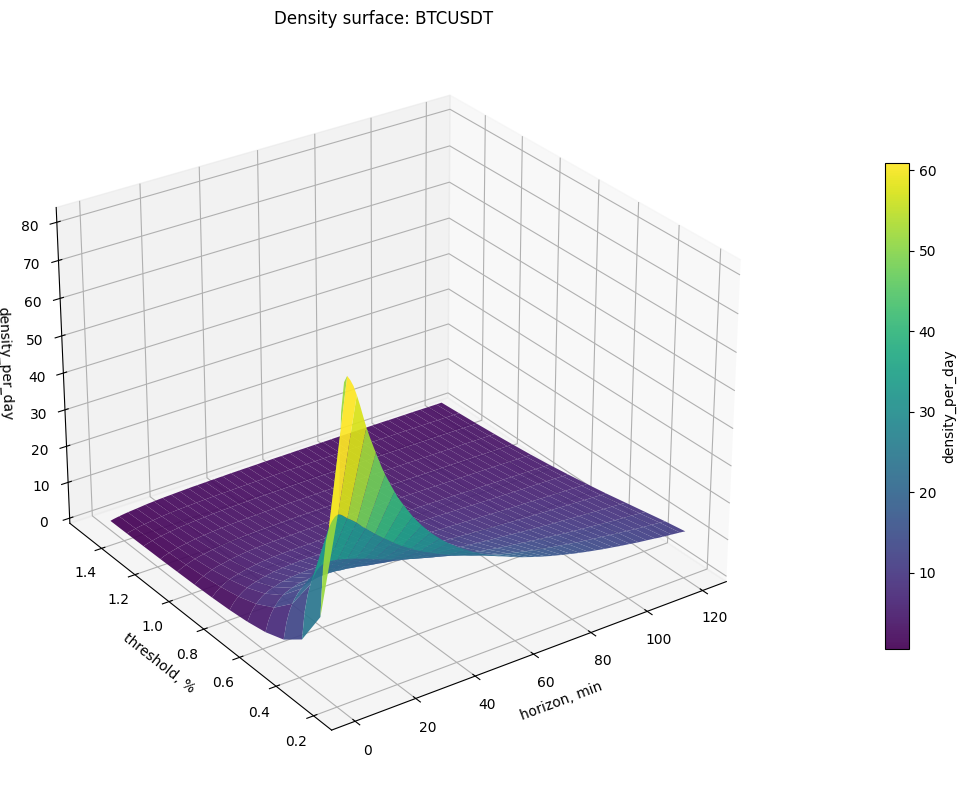

In [11]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def plot_density_surface_3d(
    density_data: pd.DataFrame,
    symbol: str,
    value_col: str = "density_per_day",
    cmap: str = "viridis",
) -> None:
    part = density_data[density_data["symbol"] == symbol].copy()

    if part.empty:
        raise ValueError(f"No rows for symbol={symbol}")

    grid = (
        part.pivot_table(
            index="threshold_pct",
            columns="horizon",
            values=value_col,
            aggfunc="mean",
        )
        .sort_index()
        .sort_index(axis=1)
    )

    X, Y = np.meshgrid(
        grid.columns.to_numpy(dtype=float),  # horizon
        grid.index.to_numpy(dtype=float),    # threshold_pct
    )
    Z = grid.to_numpy(dtype=float)

    fig = plt.figure(figsize=(13, 8))
    ax = fig.add_subplot(111, projection="3d")

    surface = ax.plot_surface(
        X,
        Y,
        Z,
        cmap=cmap,
        linewidth=0,
        antialiased=True,
        alpha=0.92,
    )

    ax.set_title(f"Density surface: {symbol}")
    ax.set_xlabel("horizon, min")
    ax.set_ylabel("threshold, %")
    ax.set_zlabel(value_col)

    fig.colorbar(surface, ax=ax, shrink=0.65, pad=0.1, label=value_col)

    ax.view_init(elev=28, azim=235)
    plt.tight_layout()


plot_density_surface_3d(density_full, "BTCUSDT")

In [19]:
import plotly.graph_objects as go

def make_wireframe_traces(
    grid: pd.DataFrame,
    line_color: str = "rgba(20,20,20,0.45)",
    line_width: int = 2,
) -> list[go.Scatter3d]:
    traces = []

    horizons = grid.columns.to_numpy(dtype=float)
    thresholds = grid.index.to_numpy(dtype=float)
    z = grid.to_numpy(dtype=float)

    # Линии вдоль horizon для каждого threshold
    for i, threshold in enumerate(thresholds):
        traces.append(
            go.Scatter3d(
                x=horizons,
                y=np.full_like(horizons, threshold, dtype=float),
                z=z[i, :],
                mode="lines",
                line=dict(color=line_color, width=line_width),
                showlegend=False,
                hoverinfo="skip",
            )
        )

    # Линии вдоль threshold для каждого horizon
    for j, horizon in enumerate(horizons):
        traces.append(
            go.Scatter3d(
                x=np.full_like(thresholds, horizon, dtype=float),
                y=thresholds,
                z=z[:, j],
                mode="lines",
                line=dict(color=line_color, width=line_width),
                showlegend=False,
                hoverinfo="skip",
            )
        )

    return traces

In [20]:
import plotly.graph_objects as go

def plot_density_surface_plotly_wireframe(
    density_data: pd.DataFrame,
    symbol: str,
    value_col: str = "density_per_day",
    surface_opacity: float = 0.86,
    wire_color: str = "rgba(20,20,20,0.42)",
    wire_width: int = 2,
) -> None:
    part = density_data[density_data["symbol"] == symbol].copy()

    if part.empty:
        raise ValueError(f"No rows for symbol={symbol}")

    grid = (
        part.pivot_table(
            index="threshold_pct",
            columns="horizon",
            values=value_col,
            aggfunc="mean",
        )
        .sort_index()
        .sort_index(axis=1)
    )

    surface = go.Surface(
        x=grid.columns,
        y=grid.index,
        z=grid.values,
        colorscale="Viridis",
        opacity=surface_opacity,
        colorbar=dict(title="событий в день"),
        showscale=True,
        hovertemplate=(
            "горизонт=%{x}<br>"
            "порог=%{y}%<br>"
            "плотность=%{z:.4f}<extra></extra>"
        ),
    )

    wireframe = make_wireframe_traces(
        grid,
        line_color=wire_color,
        line_width=wire_width,
    )

    fig = go.Figure(data=[surface, *wireframe])

    fig.update_layout(
        title=f"плотность неперекрывающихся движений: {symbol}",
        scene=dict(
            xaxis_title="горизонт, мин",
            yaxis_title="пороговое значение в %",
            zaxis_title="событий в день",
            xaxis=dict(showgrid=True, gridcolor="rgba(180,180,180,0.35)"),
            yaxis=dict(showgrid=True, gridcolor="rgba(180,180,180,0.35)"),
            zaxis=dict(showgrid=True, gridcolor="rgba(180,180,180,0.35)"),
        ),
        width=950,
        height=720,
    )

    fig.show()


plot_density_surface_plotly_wireframe(density_full, "BTCUSDT")

In [22]:
for symbol in sorted(density_full["symbol"].dropna().unique()):
    plot_density_surface_plotly_wireframe(density_full, symbol)

In [29]:
import numpy as np
import pandas as pd


def compute_post_peak_slope(
    density_data: pd.DataFrame,
    delta: int = 10,
    value_col: str = "density_per_day",
) -> pd.DataFrame:
    rows = []

    group_cols = ["symbol", "threshold_pct"]

    for (symbol, threshold_pct), part in density_data.groupby(group_cols):
        part = (
            part[["symbol", "threshold_pct", "horizon", value_col]]
            .dropna()
            .sort_values("horizon")
            .copy()
        )

        if part.empty:
            continue

        best_idx = part[value_col].idxmax()
        h_star = int(part.loc[best_idx, "horizon"])
        d_star = float(part.loc[best_idx, value_col])

        target_horizon = h_star + delta

        after = part[part["horizon"] >= target_horizon].head(1)

        if after.empty:
            d_after = np.nan
            actual_delta = np.nan
            slope = np.nan
        else:
            h_after = int(after.iloc[0]["horizon"])
            d_after = float(after.iloc[0][value_col])
            actual_delta = h_after - h_star
            slope = -(d_after - d_star) / actual_delta

        rows.append(
            {
                "symbol": symbol,
                "threshold_pct": threshold_pct,
                "h_star": h_star,
                "D_star": d_star,
                "target_horizon": target_horizon,
                "actual_horizon": np.nan if after.empty else h_after,
                "actual_delta": actual_delta,
                "D_after": d_after,
                "post_peak_slope": slope,
                "post_peak_slope_pct_of_Dmax_per_min": slope / d_star * 100 if d_star > 0 else np.nan,
            }
        )

    return pd.DataFrame(rows).sort_values(["threshold_pct", "symbol"]).reset_index(drop=True)


post_peak_slope = compute_post_peak_slope(
    density_full,
    delta=10,
    value_col="density_per_day",
)

post_peak_slope

,symbol,threshold_pct,h_star,D_star,target_horizon,actual_horizon,actual_delta,D_after,post_peak_slope,post_peak_slope_pct_of_Dmax_per_min
0,ADAUSDT,0.2,2,186.068023,12,12,10,94.846229,9.122179,4.902605
1,BCHUSDT,0.2,3,152.860128,13,13,10,84.020365,6.883976,4.503448
2,BNBUSDT,0.2,3,115.635433,13,13,10,71.913878,4.372155,3.780982
3,BTCUSDT,0.2,4,82.120157,14,14,10,58.531418,2.358874,2.872466
4,DOGEUSDT,0.2,2,185.788482,12,12,10,91.981611,9.380687,5.049122
...,...,...,...,...,...,...,...,...,...,...
121,DOGEUSDT,1.5,23,7.524842,33,33,10,7.380862,0.014398,0.191340
122,ETHUSDT,1.5,64,4.296447,74,74,10,4.275982,0.002046,0.047632
123,SOLUSDT,1.5,33,8.883645,43,43,10,8.771022,0.011262,0.126776
124,TRXUSDT,1.5,44,3.410051,54,54,10,3.392624,0.001743,0.051106


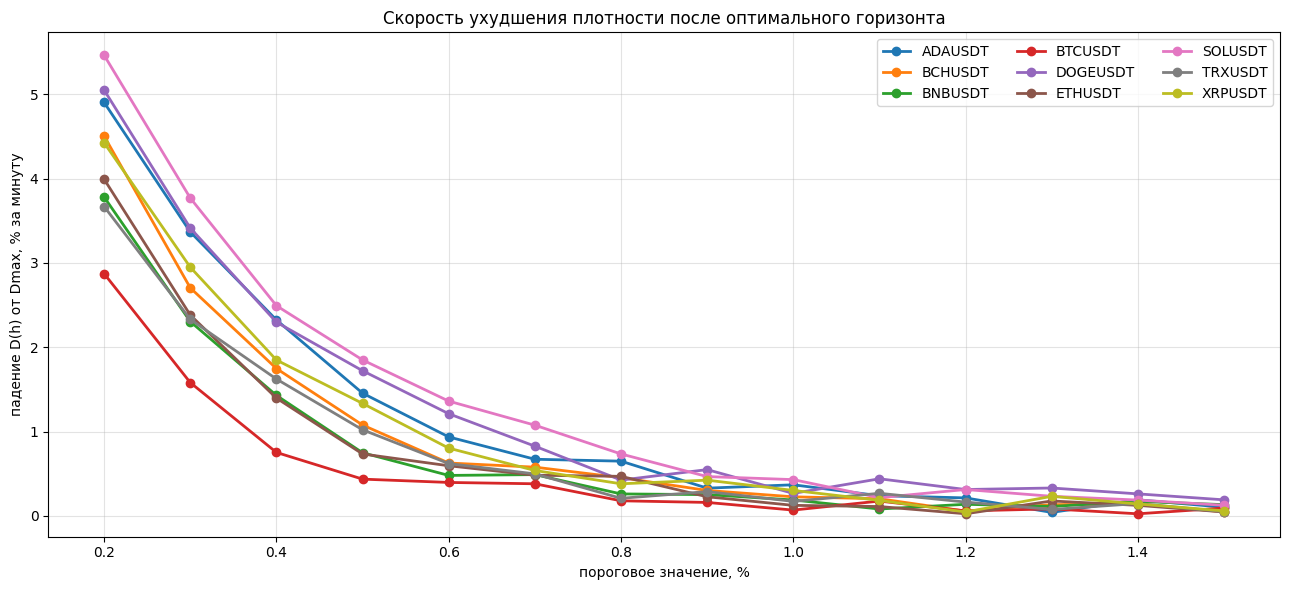

In [30]:
import matplotlib.pyplot as plt


def plot_post_peak_slope_by_threshold(
    post_peak_slope: pd.DataFrame,
    value_col: str = "post_peak_slope_pct_of_Dmax_per_min",
) -> None:
    plot_data = post_peak_slope.dropna(subset=[value_col]).copy()

    fig, ax = plt.subplots(figsize=(13, 6))

    for symbol, part in plot_data.groupby("symbol"):
        part = part.sort_values("threshold_pct")

        ax.plot(
            part["threshold_pct"],
            part[value_col],
            marker="o",
            linewidth=2,
            label=symbol,
        )

    ax.set_title("Скорость ухудшения плотности после оптимального горизонта")
    ax.set_xlabel("пороговое значение, %")
    ax.set_ylabel("падение D(h) от Dmax, % за минуту")

    ax.grid(True, alpha=0.35)
    ax.legend(ncol=3)

    plt.tight_layout()
    plt.show()


plot_post_peak_slope_by_threshold(post_peak_slope)

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except ImportError:
    sns = None


QUARTERLY_BOXPLOT_THRESHOLDS = np.round(np.arange(0.2, 0.8 + 0.001, 0.1), 1)
QUARTERLY_BOXPLOT_THRESHOLDS_RAW = (QUARTERLY_BOXPLOT_THRESHOLDS / 100.0).round(6).tolist()

selected_return_columns = [
    col for col in returns.columns
    if col != timestamp_column and col.endswith("_return")
]

print(f"return columns: {len(selected_return_columns)}")
print(selected_return_columns[:10])


def build_density_curves_for_thresholds(
    frame: pd.DataFrame,
    return_cols: list[str],
    thresholds: list[float],
) -> pd.DataFrame:
    curves = []

    for col in return_cols:
        symbol = symbol_from_return_column(col)
        print(f"Computing quarterly density curves for {symbol}...")

        curves.append(
            density_curve_for_series(
                frame[col],
                symbol=symbol,
                thresholds=thresholds,
            )
        )

    return pd.concat(curves, ignore_index=True) if curves else pd.DataFrame()


def quarterly_density_curves_for_thresholds(
    frame: pd.DataFrame,
    return_cols: list[str],
    thresholds: list[float],
    freq: str = "QE",
) -> pd.DataFrame:
    result = []

    periods = frame.set_index(timestamp_column).groupby(
        pd.Grouper(freq=normalize_pandas_freq(freq))
    )

    for period_end, period_frame in periods:
        if period_frame.empty:
            continue

        period_frame = period_frame.reset_index()

        period_start = period_frame[timestamp_column].min()
        period_finish = period_frame[timestamp_column].max()
        period_label = f"{period_end.year}-Q{period_end.quarter}"

        print(f"Period {period_label}: rows={len(period_frame):,}")

        curves = build_density_curves_for_thresholds(
            period_frame,
            return_cols=return_cols,
            thresholds=thresholds,
        )

        if curves.empty:
            continue

        curves["period_start"] = period_start
        curves["period_end"] = period_finish
        curves["period_label"] = period_label

        result.append(curves)

    return pd

return columns: 9
['BTCUSDT_return', 'ETHUSDT_return', 'BNBUSDT_return', 'DOGEUSDT_return', 'XRPUSDT_return', 'SOLUSDT_return', 'TRXUSDT_return', 'ADAUSDT_return', 'BCHUSDT_return']


In [35]:
plot_data = quarterly_summary_02_08.copy()
plot_data["threshold_pct"] = plot_data["threshold_pct"].round(1)

plot_data = plot_data[
    plot_data["threshold_pct"].isin(QUARTERLY_BOXPLOT_THRESHOLDS)
].dropna(subset=["symbol", "threshold_pct", "best_horizon"])


fig, ax = plt.subplots(figsize=(12, 6))

if sns is not None:
    sns.boxplot(
        data=plot_data,
        x="threshold_pct",
        y="best_horizon",
        color="lightsteelblue",
        ax=ax,
    )

    sns.stripplot(
        data=plot_data,
        x="threshold_pct",
        y="best_horizon",
        color="black",
        alpha=0.35,
        size=3,
        jitter=0.18,
        ax=ax,
    )
else:
    grouped = [
        plot_data.loc[
            plot_data["threshold_pct"] == threshold,
            "best_horizon",
        ].to_numpy()
        for threshold in QUARTERLY_BOXPLOT_THRESHOLDS
    ]

    ax.boxplot(
        grouped,
        labels=[f"{threshold:.1f}" for threshold in QUARTERLY_BOXPLOT_THRESHOLDS],
        showfliers=True,
    )

ax.set_title("Поквартальные оптимальные горизонты h* по порогам 0.2%-0.8%")
ax.set_xlabel("пороговое значение, %")
ax.set_ylabel("best horizon h*, мин")
ax.grid(True, axis="y", alpha=0.35)

plt.tight_layout()
plt.show()

NameError: name 'quarterly_summary_02_08' is not defined

Period 2020-Q1: rows=86,398
  BTCUSDT
  ETHUSDT
  BNBUSDT
  DOGEUSDT
  XRPUSDT
  SOLUSDT
  TRXUSDT
  ADAUSDT
  BCHUSDT
Period 2020-Q2: rows=131,032
  BTCUSDT
  ETHUSDT
  BNBUSDT
  DOGEUSDT
  XRPUSDT
  SOLUSDT
  TRXUSDT
  ADAUSDT
  BCHUSDT
Period 2020-Q3: rows=132,419
  BTCUSDT
  ETHUSDT
  BNBUSDT
  DOGEUSDT
  XRPUSDT
  SOLUSDT
  TRXUSDT
  ADAUSDT
  BCHUSDT
Period 2020-Q4: rows=132,448
  BTCUSDT
  ETHUSDT
  BNBUSDT
  DOGEUSDT
  XRPUSDT
  SOLUSDT
  TRXUSDT
  ADAUSDT
  BCHUSDT
Period 2021-Q1: rows=129,518
  BTCUSDT
  ETHUSDT
  BNBUSDT
  DOGEUSDT
  XRPUSDT
  SOLUSDT
  TRXUSDT
  ADAUSDT
  BCHUSDT
Period 2021-Q2: rows=130,949
  BTCUSDT
  ETHUSDT
  BNBUSDT
  DOGEUSDT
  XRPUSDT
  SOLUSDT
  TRXUSDT
  ADAUSDT
  BCHUSDT
Period 2021-Q3: rows=132,393
  BTCUSDT
  ETHUSDT
  BNBUSDT
  DOGEUSDT
  XRPUSDT
  SOLUSDT
  TRXUSDT
  ADAUSDT
  BCHUSDT
Period 2021-Q4: rows=132,392
  BTCUSDT
  ETHUSDT
  BNBUSDT
  DOGEUSDT
  XRPUSDT
  SOLUSDT
  TRXUSDT
  ADAUSDT
  BCHUSDT
Period 2022-Q1: rows=129,516
  BTCUSDT
  

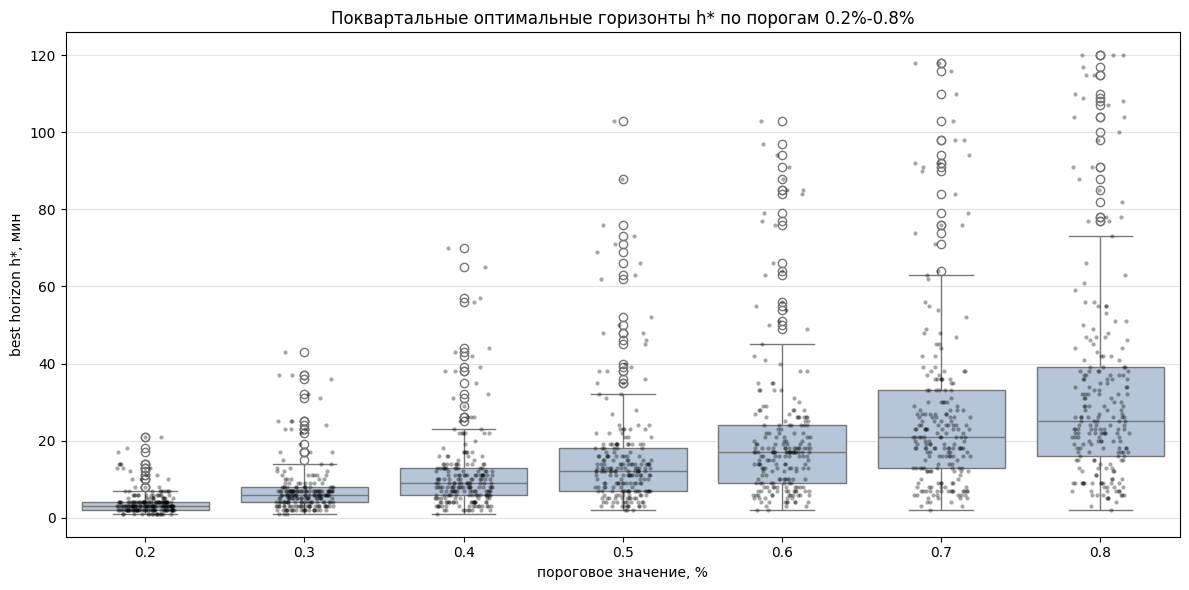

,period_label,period_start,period_end,symbol,threshold,threshold_pct,best_horizon,max_density_per_day,plateau_min_horizon,plateau_max_horizon,plateau_width
0,2020-Q1,2020-02-01 00:02:00+00:00,2020-03-31 23:59:00+00:00,ADAUSDT,0.002,0.2,2,251.388303,2,2,0
1,2020-Q1,2020-02-01 00:02:00+00:00,2020-03-31 23:59:00+00:00,ADAUSDT,0.003,0.3,3,146.725742,2,4,2
2,2020-Q1,2020-02-01 00:02:00+00:00,2020-03-31 23:59:00+00:00,ADAUSDT,0.004,0.4,4,96.169363,3,6,3
3,2020-Q1,2020-02-01 00:02:00+00:00,2020-03-31 23:59:00+00:00,ADAUSDT,0.005,0.5,5,68.422495,4,9,5
4,2020-Q1,2020-02-01 00:02:00+00:00,2020-03-31 23:59:00+00:00,ADAUSDT,0.006,0.6,7,51.334062,5,11,6


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except ImportError:
    sns = None


QUARTERLY_BOXPLOT_THRESHOLDS = np.round(np.arange(0.2, 0.8 + 0.001, 0.1), 1)
QUARTERLY_BOXPLOT_THRESHOLDS_RAW = (QUARTERLY_BOXPLOT_THRESHOLDS / 100.0).round(6).tolist()

quarterly_density_02_08_parts = []

for period_end, period_frame in returns.set_index(timestamp_column).groupby(
    pd.Grouper(freq=normalize_pandas_freq("QE"))
):
    if period_frame.empty:
        continue

    period_frame = period_frame.reset_index()

    period_start = period_frame[timestamp_column].min()
    period_finish = period_frame[timestamp_column].max()
    period_label = f"{period_end.year}-Q{period_end.quarter}"

    print(f"Period {period_label}: rows={len(period_frame):,}")

    for col in selected_return_columns:
        symbol = symbol_from_return_column(col)
        print(f"  {symbol}")

        curves = density_curve_for_series(
            period_frame[col],
            symbol=symbol,
            thresholds=QUARTERLY_BOXPLOT_THRESHOLDS_RAW,
        )

        curves["period_start"] = period_start
        curves["period_end"] = period_finish
        curves["period_label"] = period_label

        quarterly_density_02_08_parts.append(curves)


quarterly_density_02_08 = pd.concat(
    quarterly_density_02_08_parts,
    ignore_index=True,
)

quarterly_summary_02_08 = summarize_curves_by(
    quarterly_density_02_08,
    ["period_label", "period_start", "period_end", "symbol", "threshold", "threshold_pct"],
)

plot_data = quarterly_summary_02_08.copy()
plot_data["threshold_pct"] = plot_data["threshold_pct"].round(1)

plot_data = plot_data[
    plot_data["threshold_pct"].isin(QUARTERLY_BOXPLOT_THRESHOLDS)
].dropna(subset=["symbol", "threshold_pct", "best_horizon"])


fig, ax = plt.subplots(figsize=(12, 6))

if sns is not None:
    sns.boxplot(
        data=plot_data,
        x="threshold_pct",
        y="best_horizon",
        color="lightsteelblue",
        ax=ax,
    )

    sns.stripplot(
        data=plot_data,
        x="threshold_pct",
        y="best_horizon",
        color="black",
        alpha=0.35,
        size=3,
        jitter=0.18,
        ax=ax,
    )
else:
    grouped = [
        plot_data.loc[
            plot_data["threshold_pct"] == threshold,
            "best_horizon",
        ].to_numpy()
        for threshold in QUARTERLY_BOXPLOT_THRESHOLDS
    ]

    ax.boxplot(
        grouped,
        labels=[f"{threshold:.1f}" for threshold in QUARTERLY_BOXPLOT_THRESHOLDS],
        showfliers=True,
    )

ax.set_title("Поквартальные оптимальные горизонты h* по порогам 0.2%-0.8%")
ax.set_xlabel("пороговое значение, %")
ax.set_ylabel("best horizon h*, мин")
ax.grid(True, axis="y", alpha=0.35)

plt.tight_layout()
plt.show()

quarterly_summary_02_08.head()

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


DELTA_AFTER_PEAK = 10


def compute_post_peak_slope_from_density(
    density_data: pd.DataFrame,
    delta: int = 10,
    value_col: str = "density_per_day",
) -> pd.DataFrame:
    rows = []

    for (symbol, threshold_pct), part in density_data.groupby(["symbol", "threshold_pct"]):
        part = part.dropna(subset=["horizon", value_col]).sort_values("horizon").copy()

        if part.empty:
            continue

        best_idx = part[value_col].idxmax()
        best = part.loc[best_idx]

        h_star = int(best["horizon"])
        d_star = float(best[value_col])

        after = part[part["horizon"] >= h_star + delta].head(1)

        if after.empty or d_star <= 0:
            slope = np.nan
            slope_pct = np.nan
            h_after = np.nan
            d_after = np.nan
        else:
            h_after = int(after.iloc[0]["horizon"])
            d_after = float(after.iloc[0][value_col])
            actual_delta = h_after - h_star

            slope = -(d_after - d_star) / actual_delta
            slope_pct = slope / d_star * 100

        rows.append(
            {
                "symbol": symbol,
                "threshold_pct": round(float(threshold_pct), 1),
                "h_star_full_period": h_star,
                "Dmax_full_period": d_star,
                "h_after": h_after,
                "D_after": d_after,
                "post_peak_slope": slope,
                "post_peak_slope_pct_of_Dmax_per_min": slope_pct,
            }
        )

    return pd.DataFrame(rows)


post_peak_slope_02_08 = compute_post_peak_slope_from_density(
    density_full[
        density_full["threshold_pct"].round(1).between(0.2, 0.8)
    ].copy(),
    delta=DELTA_AFTER_PEAK,
)


quarterly_hstar_stability_02_08 = (
    quarterly_summary_02_08
    .assign(threshold_pct=lambda x: x["threshold_pct"].round(1))
    .query("0.2 <= threshold_pct <= 0.8")
    .groupby(["symbol", "threshold_pct"])
    .agg(
        quarters=("period_label", "nunique"),
        mean_best_horizon=("best_horizon", "mean"),
        std_best_horizon=("best_horizon", "std"),
        median_best_horizon=("best_horizon", "median"),
        min_best_horizon=("best_horizon", "min"),
        max_best_horizon=("best_horizon", "max"),
    )
    .reset_index()
)


slope_vs_hstar_std_02_08 = quarterly_hstar_stability_02_08.merge(
    post_peak_slope_02_08,
    on=["symbol", "threshold_pct"],
    how="inner",
)

slope_vs_hstar_std_02_08

,symbol,threshold_pct,quarters,mean_best_horizon,std_best_horizon,median_best_horizon,min_best_horizon,max_best_horizon,h_star_full_period,Dmax_full_period,h_after,D_after,post_peak_slope,post_peak_slope_pct_of_Dmax_per_min
0,ADAUSDT,0.2,25,2.88,1.235584,3.0,1,7,2,186.068023,12,94.846229,9.122179,4.902605
1,ADAUSDT,0.3,25,5.00,2.217356,5.0,2,12,4,103.808219,14,68.854091,3.495413,3.367183
2,ADAUSDT,0.4,25,7.68,4.230051,7.0,2,22,6,66.594939,16,51.119799,1.547514,2.323771
3,ADAUSDT,0.5,25,10.80,6.231640,11.0,3,32,7,46.676924,17,39.882088,0.679484,1.455716
4,ADAUSDT,0.6,25,13.60,7.382412,13.0,4,38,9,34.296766,19,31.082955,0.321381,0.937059
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,XRPUSDT,0.4,25,8.12,4.013726,8.0,2,17,5,54.471790,15,44.401052,1.007074,1.848799
59,XRPUSDT,0.5,25,12.16,6.094260,12.0,2,24,7,38.183011,17,33.087607,0.509540,1.334469
60,XRPUSDT,0.6,25,16.00,8.103497,16.0,3,29,8,28.094415,18,25.834726,0.225969,0.804320
61,XRPUSDT,0.7,25,20.44,11.176911,18.0,3,48,10,21.531033,20,20.369829,0.116120,0.539317


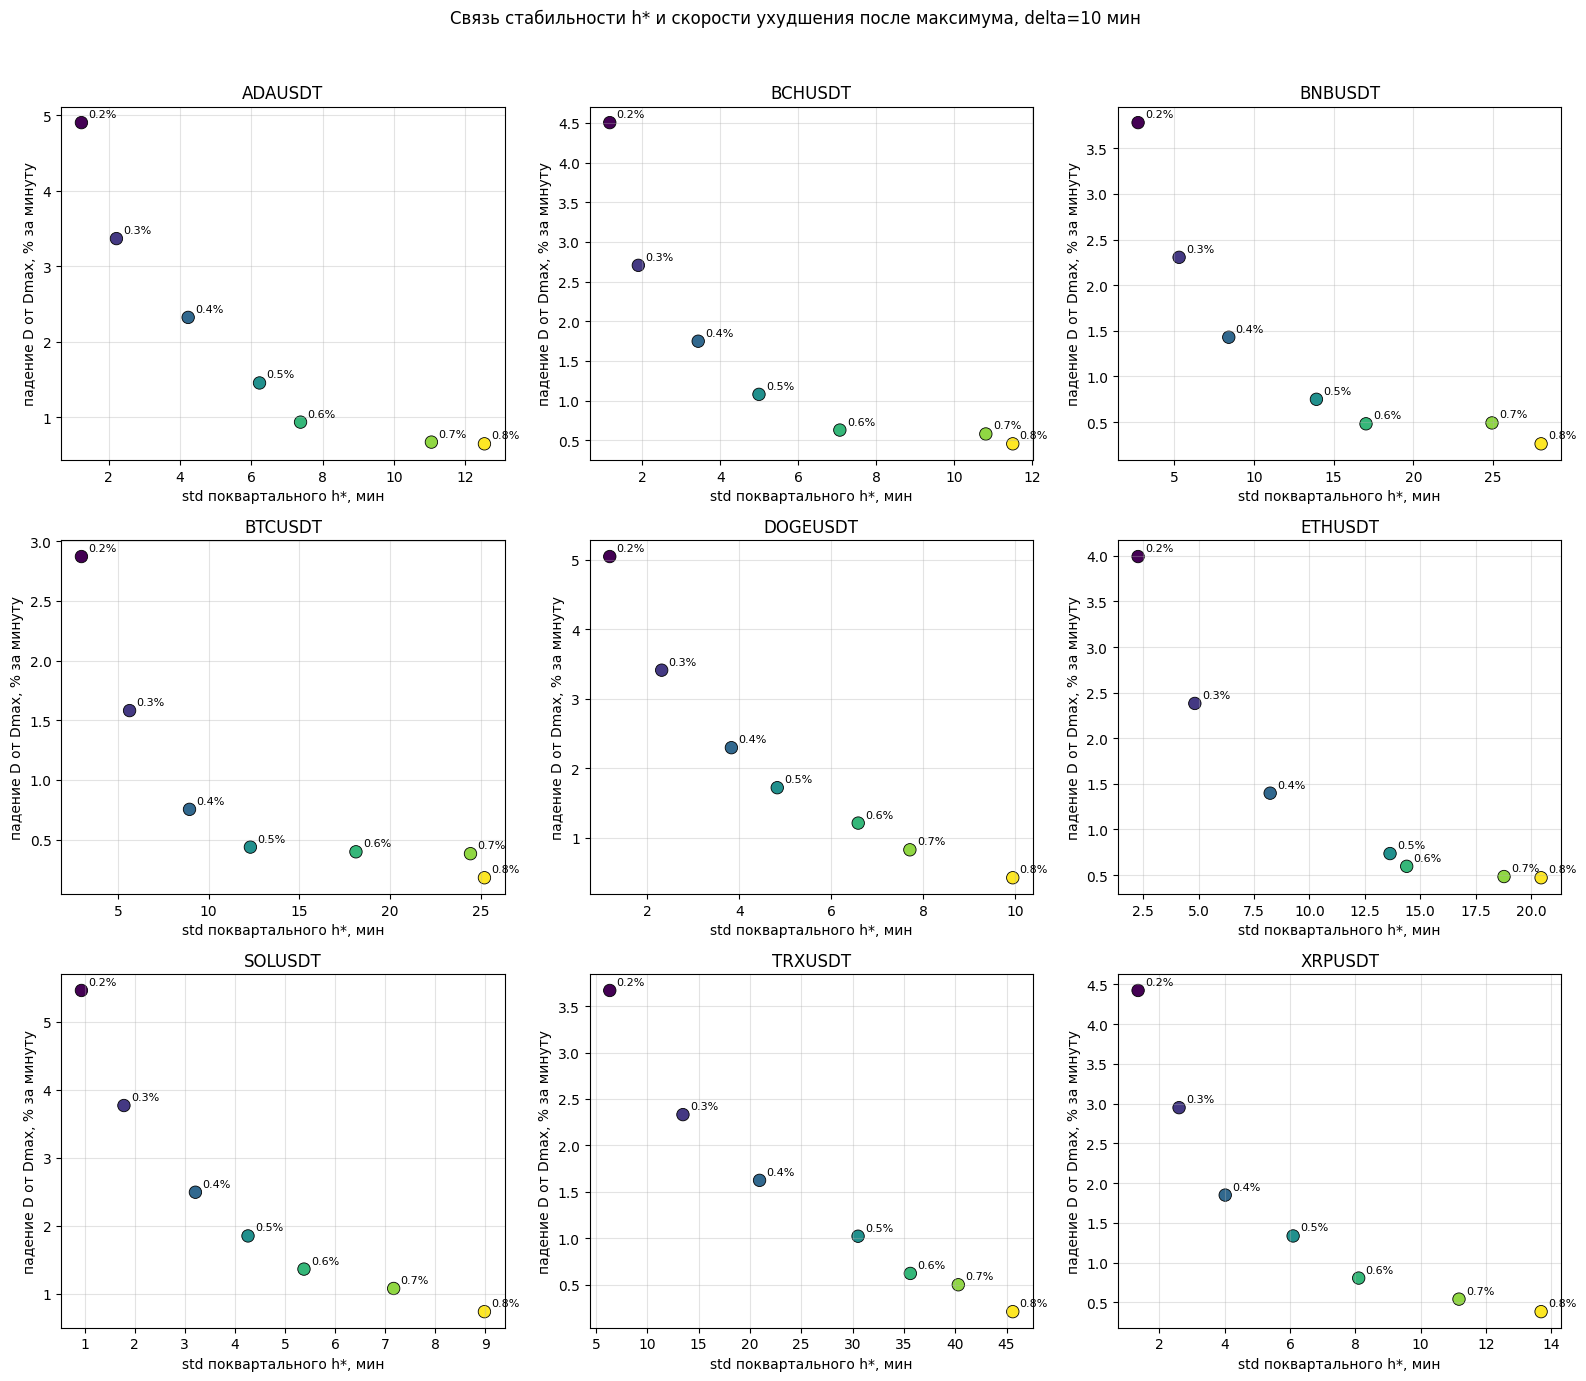

In [39]:
symbols = sorted(slope_vs_hstar_std_02_08["symbol"].unique())

ncols = 3
nrows = int(np.ceil(len(symbols) / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(16, 4.5 * nrows),
    sharex=False,
    sharey=False,
)

axes = np.asarray(axes).reshape(-1)

for ax, symbol in zip(axes, symbols):
    part = slope_vs_hstar_std_02_08[
        slope_vs_hstar_std_02_08["symbol"] == symbol
    ].sort_values("threshold_pct")

    scatter = ax.scatter(
        part["std_best_horizon"],
        part["post_peak_slope_pct_of_Dmax_per_min"],
        c=part["threshold_pct"],
        cmap="viridis",
        s=80,
        edgecolor="black",
        linewidth=0.6,
    )

    for _, row in part.iterrows():
        ax.annotate(
            f'{row["threshold_pct"]:.1f}%',
            (
                row["std_best_horizon"],
                row["post_peak_slope_pct_of_Dmax_per_min"],
            ),
            xytext=(5, 4),
            textcoords="offset points",
            fontsize=8,
        )

    ax.set_title(symbol)
    ax.set_xlabel("std поквартального h*, мин")
    ax.set_ylabel("падение D от Dmax, % за минуту")
    ax.grid(True, alpha=0.35)

for ax in axes[len(symbols):]:
    ax.axis("off")

fig.suptitle(
    f"Связь стабильности h* и скорости ухудшения после максимума, delta={DELTA_AFTER_PEAK} мин",
    y=1.02,
)

plt.tight_layout()
plt.show()

In [40]:
slope_vs_hstar_std_corr = (
    slope_vs_hstar_std_02_08
    .groupby("symbol")
    .apply(
        lambda x: x["std_best_horizon"].corr(
            x["post_peak_slope_pct_of_Dmax_per_min"]
        )
    )
    .rename("corr_std_hstar_vs_post_peak_slope")
    .reset_index()
)

slope_vs_hstar_std_corr

,symbol,corr_std_hstar_vs_post_peak_slope
0,ADAUSDT,-0.898214
1,BCHUSDT,-0.832779
2,BNBUSDT,-0.854272
3,BTCUSDT,-0.805276
4,DOGEUSDT,-0.935458
5,ETHUSDT,-0.901013
6,SOLUSDT,-0.907541
7,TRXUSDT,-0.968311
8,XRPUSDT,-0.885829


In [41]:
import numpy as np
import pandas as pd


def compute_post_peak_slope_from_density_relative(
    density_data: pd.DataFrame,
    relative_delta: float = 0.2,
    min_delta: int = 1,
    value_col: str = "density_per_day",
) -> pd.DataFrame:
    rows = []

    for (symbol, threshold_pct), part in density_data.groupby(["symbol", "threshold_pct"]):
        part = part.dropna(subset=["horizon", value_col]).sort_values("horizon").copy()

        if part.empty:
            continue

        best_idx = part[value_col].idxmax()
        best = part.loc[best_idx]

        h_star = int(best["horizon"])
        d_star = float(best[value_col])

        delta = max(min_delta, int(round(relative_delta * h_star)))
        target_horizon = h_star + delta

        after = part[part["horizon"] >= target_horizon].head(1)

        if after.empty or d_star <= 0:
            h_after = np.nan
            d_after = np.nan
            actual_delta = np.nan
            slope = np.nan
            slope_pct = np.nan
        else:
            h_after = int(after.iloc[0]["horizon"])
            d_after = float(after.iloc[0][value_col])
            actual_delta = h_after - h_star

            slope = (d_star - d_after) / actual_delta
            slope_pct = slope / d_star * 100

        rows.append(
            {
                "symbol": symbol,
                "threshold_pct": round(float(threshold_pct), 1),
                "h_star_full_period": h_star,
                "Dmax_full_period": d_star,
                "relative_delta": relative_delta,
                "target_delta": delta,
                "target_horizon": target_horizon,
                "actual_horizon": h_after,
                "actual_delta": actual_delta,
                "D_after": d_after,
                "post_peak_slope_relative": slope,
                "post_peak_slope_relative_pct_of_Dmax_per_min": slope_pct,
            }
        )

    return pd.DataFrame(rows)


post_peak_slope_relative_02_08 = compute_post_peak_slope_from_density_relative(
    density_full[
        density_full["threshold_pct"].round(1).between(0.2, 0.8)
    ].copy(),
    relative_delta=0.2,
)

post_peak_slope_relative_02_08

,symbol,threshold_pct,h_star_full_period,Dmax_full_period,relative_delta,target_delta,target_horizon,actual_horizon,actual_delta,D_after,post_peak_slope_relative,post_peak_slope_relative_pct_of_Dmax_per_min
0,ADAUSDT,0.2,2,186.068023,0.2,1,3,3,1,181.668363,4.399660,2.364544
1,ADAUSDT,0.3,4,103.808219,0.2,1,5,5,1,101.345833,2.462386,2.372053
2,ADAUSDT,0.4,6,66.594939,0.2,1,7,7,1,65.776281,0.818658,1.229310
3,ADAUSDT,0.5,7,46.676924,0.2,1,8,8,1,46.598755,0.078169,0.167468
4,ADAUSDT,0.6,9,34.296766,0.2,2,11,11,2,34.135785,0.080490,0.234687
...,...,...,...,...,...,...,...,...,...,...,...,...
58,XRPUSDT,0.4,5,54.471790,0.2,1,6,6,1,54.453772,0.018018,0.033078
59,XRPUSDT,0.5,7,38.183011,0.2,1,8,8,1,37.959839,0.223172,0.584479
60,XRPUSDT,0.6,8,28.094415,0.2,2,10,10,2,27.802208,0.146104,0.520046
61,XRPUSDT,0.7,10,21.531033,0.2,2,12,12,2,21.488456,0.021288,0.098873


In [42]:
quarterly_hstar_stability_02_08 = (
    quarterly_summary_02_08
    .assign(threshold_pct=lambda x: x["threshold_pct"].round(1))
    .query("0.2 <= threshold_pct <= 0.8")
    .groupby(["symbol", "threshold_pct"])
    .agg(
        quarters=("period_label", "nunique"),
        mean_best_horizon=("best_horizon", "mean"),
        std_best_horizon=("best_horizon", "std"),
        median_best_horizon=("best_horizon", "median"),
        min_best_horizon=("best_horizon", "min"),
        max_best_horizon=("best_horizon", "max"),
    )
    .reset_index()
)


slope_relative_vs_hstar_std_02_08 = quarterly_hstar_stability_02_08.merge(
    post_peak_slope_relative_02_08,
    on=["symbol", "threshold_pct"],
    how="inner",
)

slope_relative_vs_hstar_std_02_08

,symbol,threshold_pct,quarters,mean_best_horizon,std_best_horizon,median_best_horizon,min_best_horizon,max_best_horizon,h_star_full_period,Dmax_full_period,relative_delta,target_delta,target_horizon,actual_horizon,actual_delta,D_after,post_peak_slope_relative,post_peak_slope_relative_pct_of_Dmax_per_min
0,ADAUSDT,0.2,25,2.88,1.235584,3.0,1,7,2,186.068023,0.2,1,3,3,1,181.668363,4.399660,2.364544
1,ADAUSDT,0.3,25,5.00,2.217356,5.0,2,12,4,103.808219,0.2,1,5,5,1,101.345833,2.462386,2.372053
2,ADAUSDT,0.4,25,7.68,4.230051,7.0,2,22,6,66.594939,0.2,1,7,7,1,65.776281,0.818658,1.229310
3,ADAUSDT,0.5,25,10.80,6.231640,11.0,3,32,7,46.676924,0.2,1,8,8,1,46.598755,0.078169,0.167468
4,ADAUSDT,0.6,25,13.60,7.382412,13.0,4,38,9,34.296766,0.2,2,11,11,2,34.135785,0.080490,0.234687
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,XRPUSDT,0.4,25,8.12,4.013726,8.0,2,17,5,54.471790,0.2,1,6,6,1,54.453772,0.018018,0.033078
59,XRPUSDT,0.5,25,12.16,6.094260,12.0,2,24,7,38.183011,0.2,1,8,8,1,37.959839,0.223172,0.584479
60,XRPUSDT,0.6,25,16.00,8.103497,16.0,3,29,8,28.094415,0.2,2,10,10,2,27.802208,0.146104,0.520046
61,XRPUSDT,0.7,25,20.44,11.176911,18.0,3,48,10,21.531033,0.2,2,12,12,2,21.488456,0.021288,0.098873


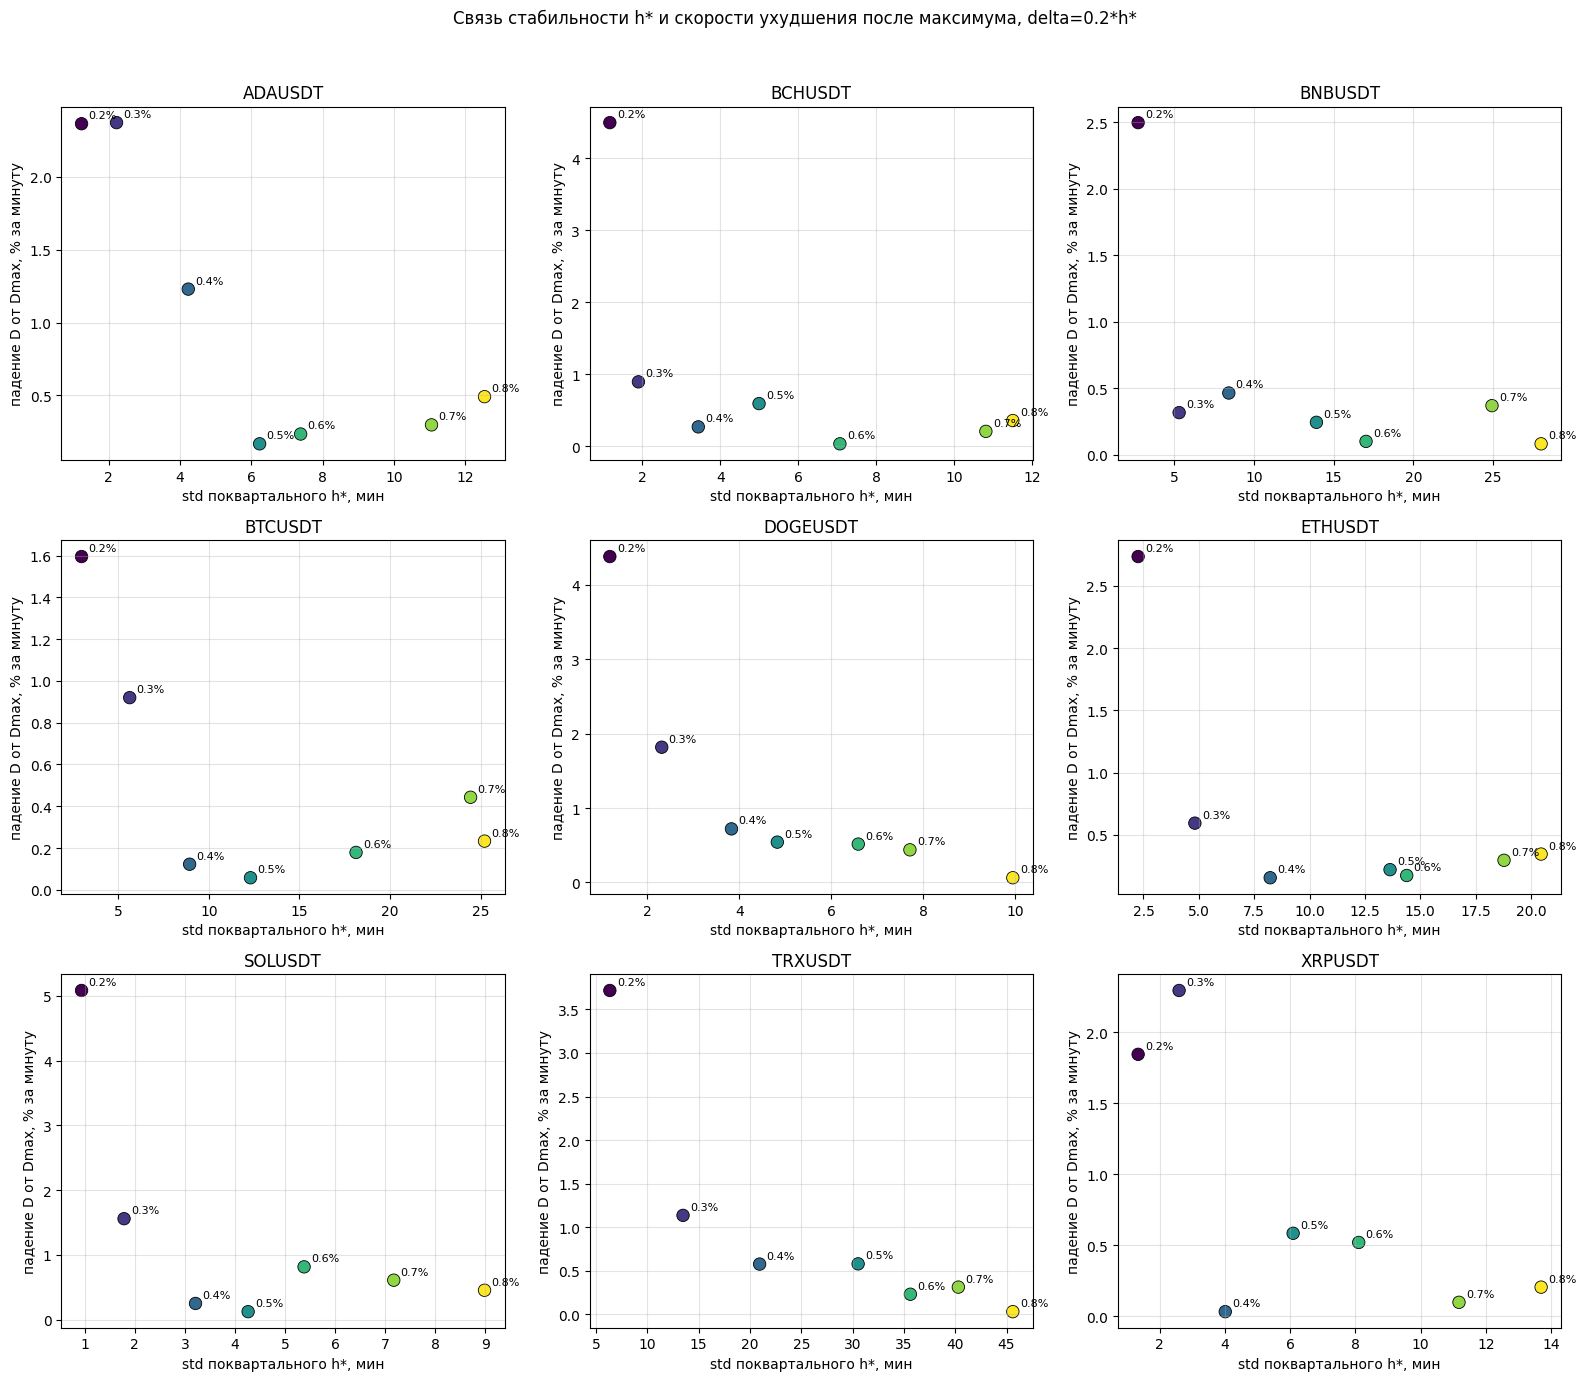

In [43]:
import matplotlib.pyplot as plt

symbols = sorted(slope_relative_vs_hstar_std_02_08["symbol"].unique())

ncols = 3
nrows = int(np.ceil(len(symbols) / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(16, 4.5 * nrows),
    sharex=False,
    sharey=False,
)

axes = np.asarray(axes).reshape(-1)

for ax, symbol in zip(axes, symbols):
    part = slope_relative_vs_hstar_std_02_08[
        slope_relative_vs_hstar_std_02_08["symbol"] == symbol
    ].sort_values("threshold_pct")

    ax.scatter(
        part["std_best_horizon"],
        part["post_peak_slope_relative_pct_of_Dmax_per_min"],
        c=part["threshold_pct"],
        cmap="viridis",
        s=80,
        edgecolor="black",
        linewidth=0.6,
    )

    for _, row in part.iterrows():
        ax.annotate(
            f'{row["threshold_pct"]:.1f}%',
            (
                row["std_best_horizon"],
                row["post_peak_slope_relative_pct_of_Dmax_per_min"],
            ),
            xytext=(5, 4),
            textcoords="offset points",
            fontsize=8,
        )

    ax.set_title(symbol)
    ax.set_xlabel("std поквартального h*, мин")
    ax.set_ylabel("падение D от Dmax, % за минуту")
    ax.grid(True, alpha=0.35)

for ax in axes[len(symbols):]:
    ax.axis("off")

fig.suptitle(
    "Связь стабильности h* и скорости ухудшения после максимума, delta=0.2*h*",
    y=1.02,
)

plt.tight_layout()
plt.show()

In [44]:
slope_relative_vs_hstar_std_corr = (
    slope_relative_vs_hstar_std_02_08
    .groupby("symbol")
    .apply(
        lambda x: x["std_best_horizon"].corr(
            x["post_peak_slope_relative_pct_of_Dmax_per_min"]
        )
    )
    .rename("corr_std_hstar_vs_relative_post_peak_slope")
    .reset_index()
)

slope_relative_vs_hstar_std_corr

,symbol,corr_std_hstar_vs_relative_post_peak_slope
0,ADAUSDT,-0.804402
1,BCHUSDT,-0.578973
2,BNBUSDT,-0.593305
3,BTCUSDT,-0.597013
4,DOGEUSDT,-0.788099
5,ETHUSDT,-0.642916
6,SOLUSDT,-0.616840
7,TRXUSDT,-0.818681
8,XRPUSDT,-0.699882


In [45]:
import numpy as np
import pandas as pd


def compute_localization_loss_threshold(
    density_data: pd.DataFrame,
    delta: int = 10,
    value_col: str = "density_per_day",
) -> pd.DataFrame:
    rows = []

    data = density_data.copy()
    data["threshold_pct"] = data["threshold_pct"].round(1)

    for (symbol, threshold_pct), part in data.groupby(["symbol", "threshold_pct"]):
        part = part.dropna(subset=["horizon", value_col]).sort_values("horizon").copy()

        if part.empty:
            continue

        best_idx = part[value_col].idxmax()
        best = part.loc[best_idx]

        h_star = int(best["horizon"])
        d_star = float(best[value_col])
        target_horizon = h_star + delta

        after = part[part["horizon"] >= target_horizon].head(1)

        if after.empty or d_star <= 0:
            h_after = np.nan
            d_after = np.nan
            ratio = np.nan
        else:
            h_after = int(after.iloc[0]["horizon"])
            d_after = float(after.iloc[0][value_col])
            ratio = d_after / d_star

        rows.append(
            {
                "symbol": symbol,
                "threshold_pct": threshold_pct,
                "h_star": h_star,
                "D_star": d_star,
                "target_horizon": target_horizon,
                "actual_horizon": h_after,
                "D_after": d_after,
                "localization_retention_R": ratio,
                "localization_loss_1_minus_R": 1 - ratio if pd.notna(ratio) else np.nan,
            }
        )

    return (
        pd.DataFrame(rows)
        .sort_values(["symbol", "threshold_pct"])
        .reset_index(drop=True)
    )


localization_02_15 = compute_localization_loss_threshold(
    density_full[
        density_full["threshold_pct"].round(1).between(0.2, 1.5)
    ],
    delta=10,
)

localization_02_15

,symbol,threshold_pct,h_star,D_star,target_horizon,actual_horizon,D_after,localization_retention_R,localization_loss_1_minus_R
0,ADAUSDT,0.2,2,186.068023,12,12,94.846229,0.509740,0.490260
1,ADAUSDT,0.3,4,103.808219,14,14,68.854091,0.663282,0.336718
2,ADAUSDT,0.4,6,66.594939,16,16,51.119799,0.767623,0.232377
3,ADAUSDT,0.5,7,46.676924,17,17,39.882088,0.854428,0.145572
4,ADAUSDT,0.6,9,34.296766,19,19,31.082955,0.906294,0.093706
...,...,...,...,...,...,...,...,...,...
121,XRPUSDT,1.1,19,9.860837,29,29,9.678665,0.981526,0.018474
122,XRPUSDT,1.2,18,8.431644,28,28,8.391508,0.995240,0.004760
123,XRPUSDT,1.3,27,7.318854,37,37,7.148481,0.976721,0.023279
124,XRPUSDT,1.4,28,6.425476,38,38,6.334029,0.985768,0.014232


In [54]:
localization_R = []
for i in range(1, 25):
    localization_R.append(compute_localization_loss_threshold(
        density_full[
            density_full["threshold_pct"].round(1).between(0.2, 1.5)
        ],
        delta= i,
    ))

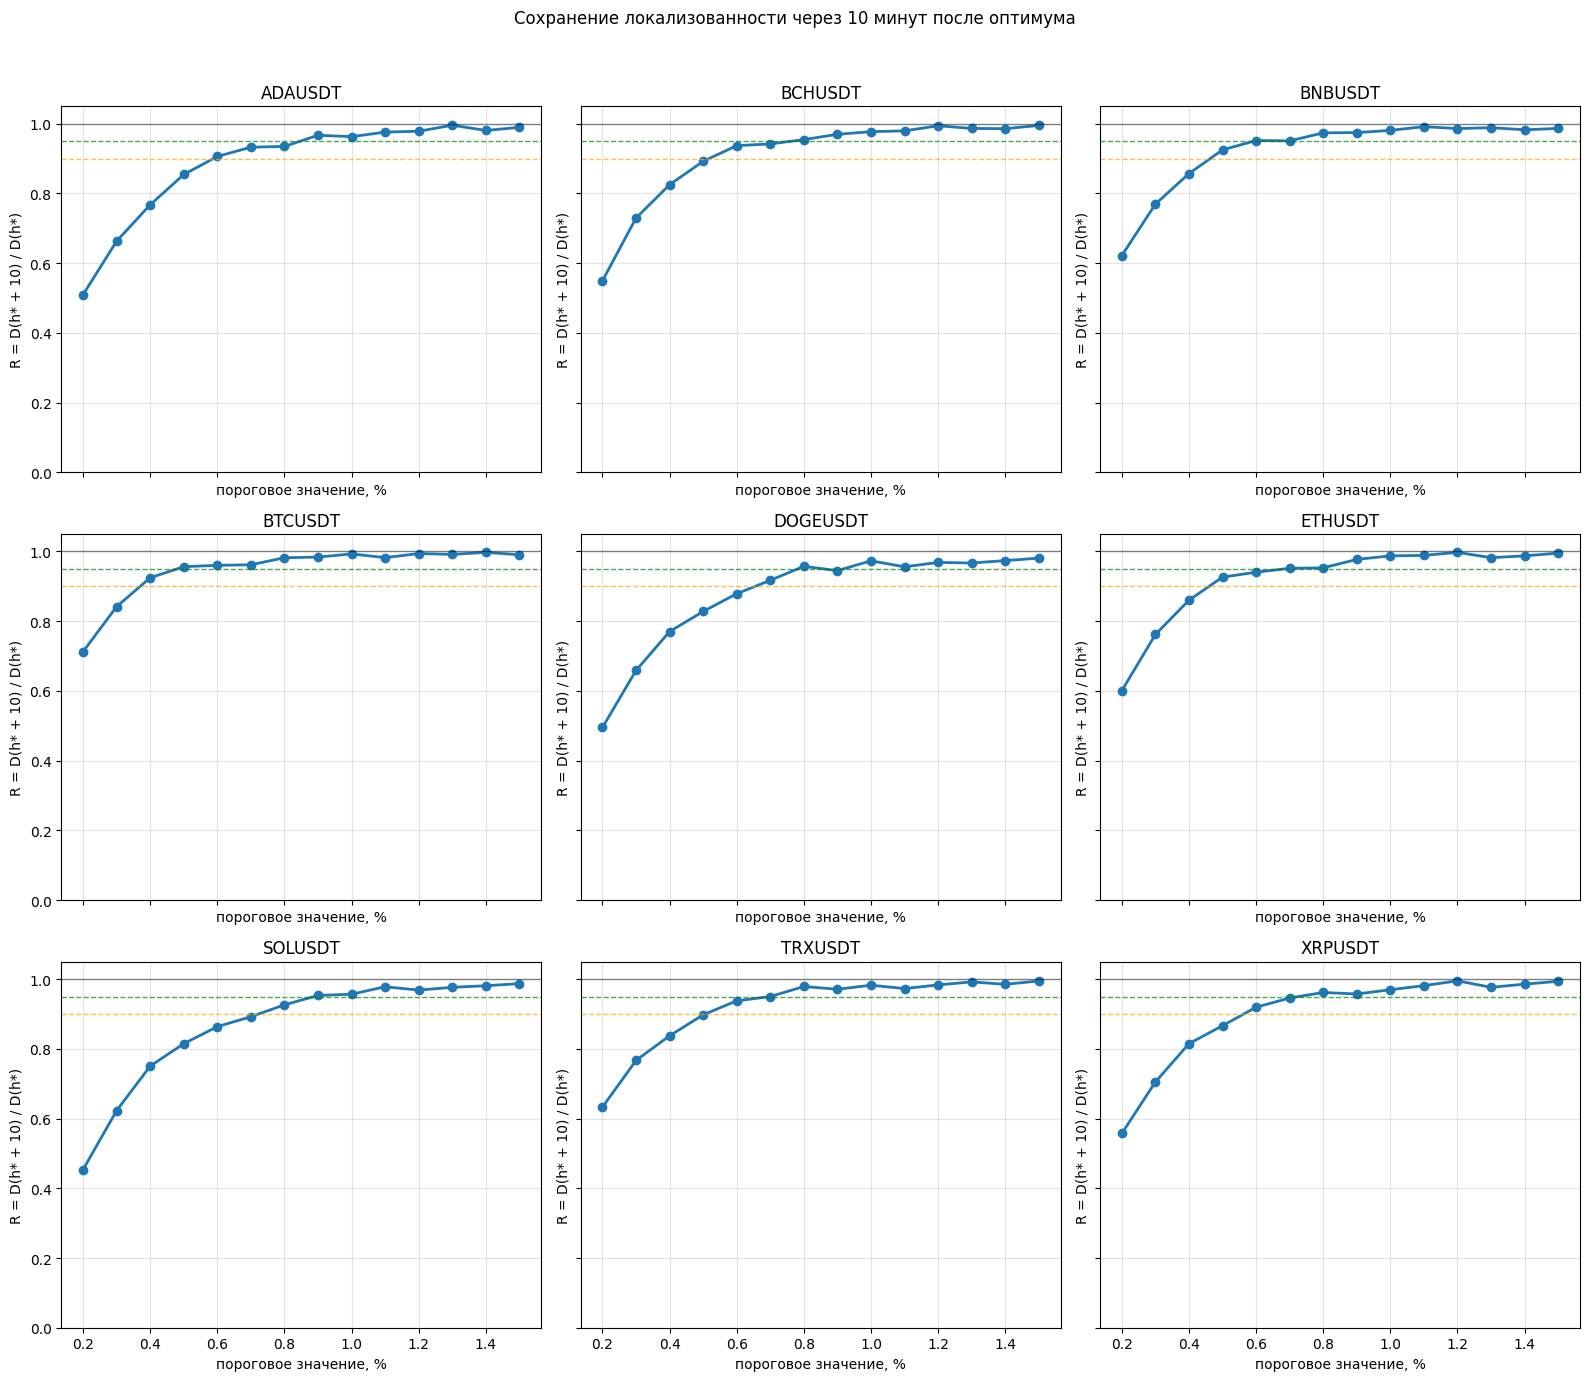

In [46]:
import matplotlib.pyplot as plt

symbols = sorted(localization_02_15["symbol"].unique())

ncols = 3
nrows = int(np.ceil(len(symbols) / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(16, 4.5 * nrows),
    sharex=True,
    sharey=True,
)

axes = np.asarray(axes).reshape(-1)

for ax, symbol in zip(axes, symbols):
    part = localization_02_15[
        localization_02_15["symbol"] == symbol
    ].sort_values("threshold_pct")

    ax.plot(
        part["threshold_pct"],
        part["localization_retention_R"],
        marker="o",
        linewidth=2,
    )

    ax.axhline(1.0, color="black", linewidth=1, alpha=0.45)
    ax.axhline(0.95, color="green", linestyle="--", linewidth=1, alpha=0.7)
    ax.axhline(0.90, color="orange", linestyle="--", linewidth=1, alpha=0.7)

    ax.set_title(symbol)
    ax.set_xlabel("пороговое значение, %")
    ax.set_ylabel("R = D(h* + 10) / D(h*)")
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.35)

for ax in axes[len(symbols):]:
    ax.axis("off")

fig.suptitle("Сохранение локализованности через 10 минут после оптимума", y=1.02)
plt.tight_layout()
plt.show()

In [47]:
quarterly_summary_for_stability = quarterly_summary_02_08.copy()

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


quarterly_hstar_stability = (
    quarterly_summary_for_stability
    .assign(threshold_pct=lambda x: x["threshold_pct"].round(1))
    .query("0.2 <= threshold_pct <= 1.5")
    .groupby(["symbol", "threshold_pct"])
    .agg(
        quarters=("period_label", "nunique"),
        mean_best_horizon=("best_horizon", "mean"),
        std_best_horizon=("best_horizon", "std"),
        median_best_horizon=("best_horizon", "median"),
        min_best_horizon=("best_horizon", "min"),
        max_best_horizon=("best_horizon", "max"),
    )
    .reset_index()
)


retention_vs_stability = quarterly_hstar_stability.merge(
    localization_02_15[
        [
            "symbol",
            "threshold_pct",
            "h_star",
            "D_star",
            "actual_horizon",
            "D_after",
            "localization_retention_R",
            "localization_loss_1_minus_R",
        ]
    ],
    on=["symbol", "threshold_pct"],
    how="inner",
)

retention_vs_stability

,symbol,threshold_pct,quarters,mean_best_horizon,std_best_horizon,median_best_horizon,min_best_horizon,max_best_horizon,h_star,D_star,actual_horizon,D_after,localization_retention_R,localization_loss_1_minus_R
0,ADAUSDT,0.2,25,2.88,1.235584,3.0,1,7,2,186.068023,12,94.846229,0.509740,0.490260
1,ADAUSDT,0.3,25,5.00,2.217356,5.0,2,12,4,103.808219,14,68.854091,0.663282,0.336718
2,ADAUSDT,0.4,25,7.68,4.230051,7.0,2,22,6,66.594939,16,51.119799,0.767623,0.232377
3,ADAUSDT,0.5,25,10.80,6.231640,11.0,3,32,7,46.676924,17,39.882088,0.854428,0.145572
4,ADAUSDT,0.6,25,13.60,7.382412,13.0,4,38,9,34.296766,19,31.082955,0.906294,0.093706
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,XRPUSDT,0.4,25,8.12,4.013726,8.0,2,17,5,54.471790,15,44.401052,0.815120,0.184880
59,XRPUSDT,0.5,25,12.16,6.094260,12.0,2,24,7,38.183011,17,33.087607,0.866553,0.133447
60,XRPUSDT,0.6,25,16.00,8.103497,16.0,3,29,8,28.094415,18,25.834726,0.919568,0.080432
61,XRPUSDT,0.7,25,20.44,11.176911,18.0,3,48,10,21.531033,20,20.369829,0.946068,0.053932


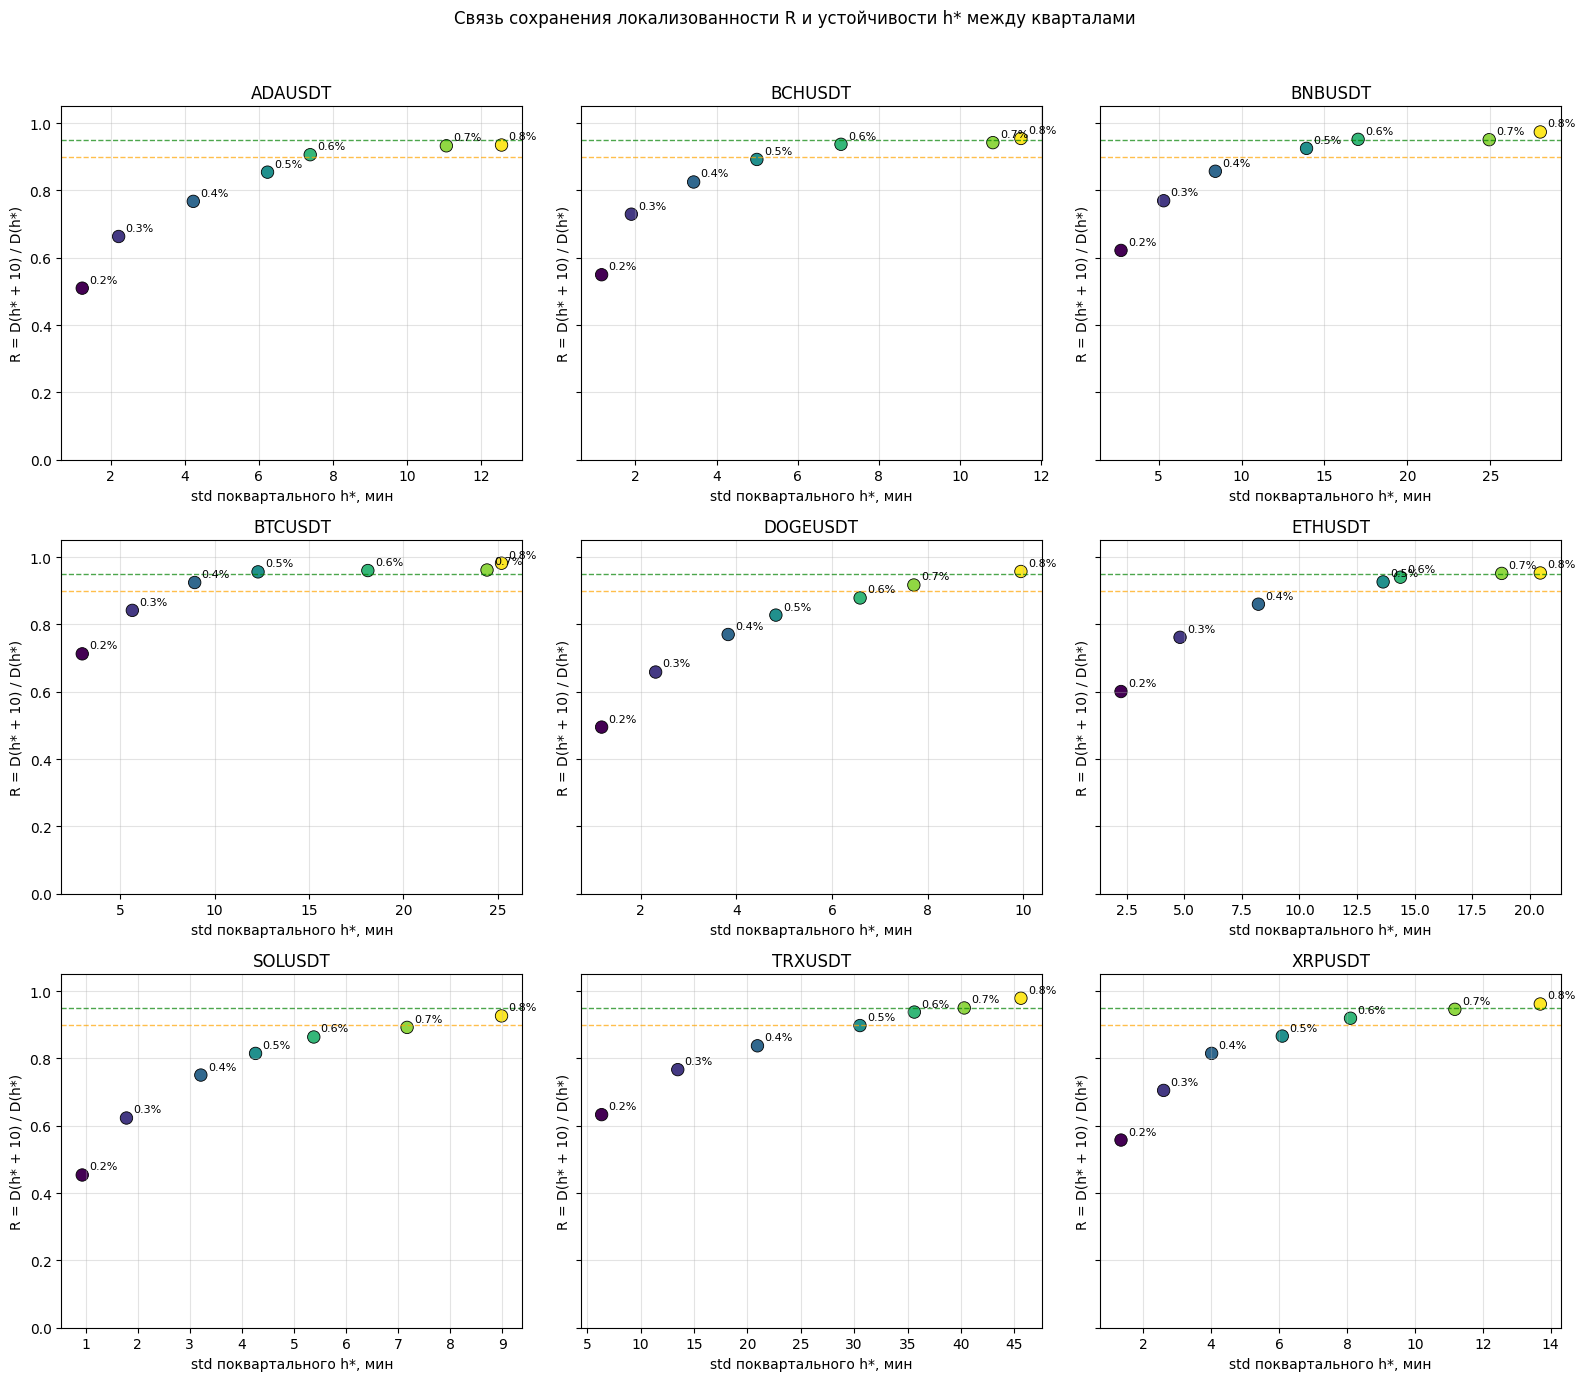

In [49]:
symbols = sorted(retention_vs_stability["symbol"].unique())

ncols = 3
nrows = int(np.ceil(len(symbols) / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(16, 4.5 * nrows),
    sharex=False,
    sharey=True,
)

axes = np.asarray(axes).reshape(-1)

for ax, symbol in zip(axes, symbols):
    part = retention_vs_stability[
        retention_vs_stability["symbol"] == symbol
    ].sort_values("threshold_pct")

    ax.scatter(
        part["std_best_horizon"],
        part["localization_retention_R"],
        c=part["threshold_pct"],
        cmap="viridis",
        s=80,
        edgecolor="black",
        linewidth=0.6,
    )

    for _, row in part.iterrows():
        ax.annotate(
            f'{row["threshold_pct"]:.1f}%',
            (
                row["std_best_horizon"],
                row["localization_retention_R"],
            ),
            xytext=(5, 4),
            textcoords="offset points",
            fontsize=8,
        )

    ax.axhline(0.95, color="green", linestyle="--", linewidth=1, alpha=0.7)
    ax.axhline(0.90, color="orange", linestyle="--", linewidth=1, alpha=0.7)

    ax.set_title(symbol)
    ax.set_xlabel("std поквартального h*, мин")
    ax.set_ylabel("R = D(h* + 10) / D(h*)")
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.35)

for ax in axes[len(symbols):]:
    ax.axis("off")

fig.suptitle("Связь сохранения локализованности R и устойчивости h* между кварталами", y=1.02)
plt.tight_layout()
plt.show()

In [50]:
retention_vs_stability_corr = (
    retention_vs_stability
    .groupby("symbol")
    .apply(
        lambda x: x["std_best_horizon"].corr(
            x["localization_retention_R"]
        )
    )
    .rename("corr_std_hstar_vs_retention_R")
    .reset_index()
)

retention_vs_stability_corr

,symbol,corr_std_hstar_vs_retention_R
0,ADAUSDT,0.898214
1,BCHUSDT,0.832779
2,BNBUSDT,0.854272
3,BTCUSDT,0.805276
4,DOGEUSDT,0.935458
5,ETHUSDT,0.901013
6,SOLUSDT,0.907541
7,TRXUSDT,0.968311
8,XRPUSDT,0.885829


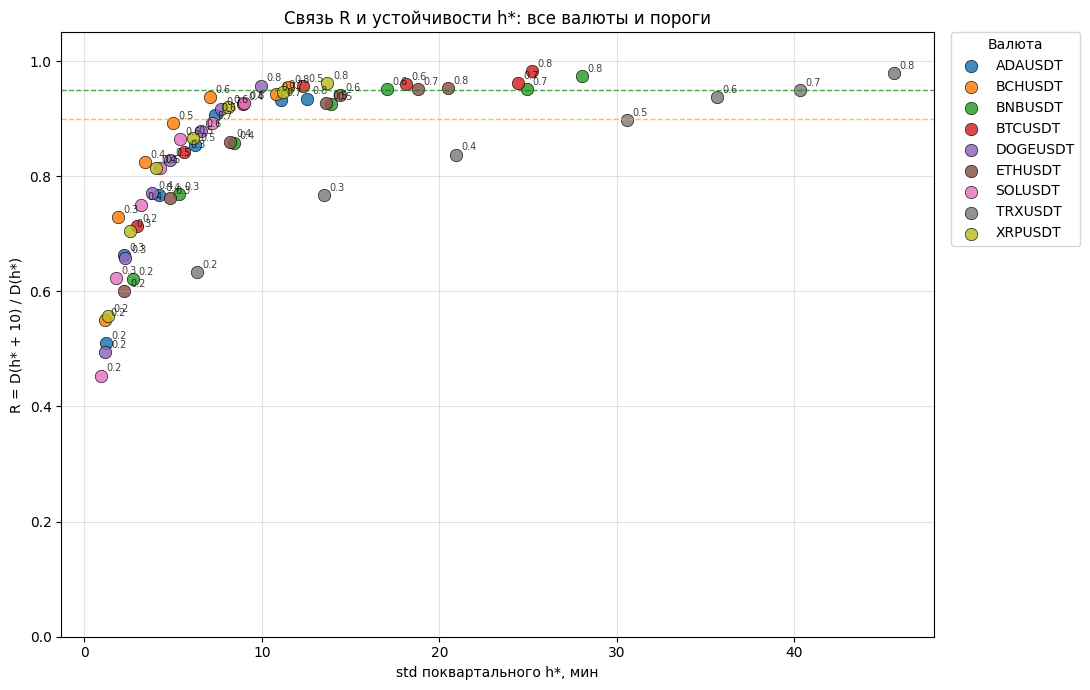

In [53]:
import matplotlib.pyplot as plt

plot_data = retention_vs_stability.dropna(
    subset=["std_best_horizon", "localization_retention_R"]
).copy()

symbols = sorted(plot_data["symbol"].unique())

fig, ax = plt.subplots(figsize=(11, 7))

for symbol in symbols:
    part = plot_data[plot_data["symbol"] == symbol].sort_values("threshold_pct")

    ax.scatter(
        part["std_best_horizon"],
        part["localization_retention_R"],
        s=80,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.5,
        label=symbol,
    )

    for _, row in part.iterrows():
        ax.annotate(
            f'{row["threshold_pct"]:.1f}',
            (
                row["std_best_horizon"],
                row["localization_retention_R"],
            ),
            xytext=(4, 3),
            textcoords="offset points",
            fontsize=7,
            alpha=0.75,
        )

ax.axhline(0.95, color="green", linestyle="--", linewidth=1, alpha=0.7)
ax.axhline(0.90, color="orange", linestyle="--", linewidth=1, alpha=0.7)

ax.set_title("Связь R и устойчивости h*: все валюты и пороги")
ax.set_xlabel("std поквартального h*, мин")
ax.set_ylabel("R = D(h* + 10) / D(h*)")
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.35)

ax.legend(
    title="Валюта",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
)

plt.tight_layout()
plt.show()

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


DELTAS_R = list(range(1, 21))


def compute_retention_R_for_deltas(
    density_data: pd.DataFrame,
    deltas: list[int],
    value_col: str = "density_per_day",
) -> pd.DataFrame:
    rows = []

    data = density_data.copy()
    data["threshold_pct"] = data["threshold_pct"].round(1)

    for (symbol, threshold_pct), part in data.groupby(["symbol", "threshold_pct"]):
        part = part.dropna(subset=["horizon", value_col]).sort_values("horizon").copy()

        if part.empty:
            continue

        best_idx = part[value_col].idxmax()
        best = part.loc[best_idx]

        h_star = int(best["horizon"])
        d_star = float(best[value_col])

        for delta in deltas:
            target_horizon = h_star + delta
            after = part[part["horizon"] >= target_horizon].head(1)

            if after.empty or d_star <= 0:
                actual_horizon = np.nan
                d_after = np.nan
                r_value = np.nan
            else:
                actual_horizon = int(after.iloc[0]["horizon"])
                d_after = float(after.iloc[0][value_col])
                r_value = d_after / d_star

            rows.append(
                {
                    "symbol": symbol,
                    "threshold_pct": threshold_pct,
                    "delta": delta,
                    "h_star": h_star,
                    "D_star": d_star,
                    "target_horizon": target_horizon,
                    "actual_horizon": actual_horizon,
                    "D_after": d_after,
                    "R": r_value,
                    "loss_1_minus_R": 1 - r_value if pd.notna(r_value) else np.nan,
                }
            )

    return pd.DataFrame(rows)


def quarterly_hstar_stability_from_summary(
    quarterly_summary: pd.DataFrame,
) -> pd.DataFrame:
    data = quarterly_summary.copy()
    data["threshold_pct"] = data["threshold_pct"].round(1)

    return (
        data
        .dropna(subset=["symbol", "threshold_pct", "best_horizon"])
        .groupby(["symbol", "threshold_pct"])
        .agg(
            quarters=("period_label", "nunique"),
            mean_best_horizon=("best_horizon", "mean"),
            std_best_horizon=("best_horizon", "std"),
            median_best_horizon=("best_horizon", "median"),
            min_best_horizon=("best_horizon", "min"),
            max_best_horizon=("best_horizon", "max"),
        )
        .reset_index()
    )


# В sweep-ноутбуке обычно это summary_quarterly.
# Если у тебя переменная называется иначе, замени тут.
quarterly_summary_for_stability = summary_quarterly.copy()

hstar_stability = quarterly_hstar_stability_from_summary(
    quarterly_summary_for_stability
)

retention_R_by_delta = compute_retention_R_for_deltas(
    density_full,
    deltas=DELTAS_R,
)

retention_R_vs_stability = retention_R_by_delta.merge(
    hstar_stability,
    on=["symbol", "threshold_pct"],
    how="inner",
)

retention_R_vs_stability.head()

,symbol,threshold_pct,delta,h_star,D_star,target_horizon,actual_horizon,D_after,R,loss_1_minus_R,quarters,mean_best_horizon,std_best_horizon,median_best_horizon,min_best_horizon,max_best_horizon
0,ADAUSDT,0.2,1,2,186.068023,3,3,181.668363,0.976355,0.023645,25,2.88,1.235584,3.0,1.0,7.0
1,ADAUSDT,0.2,2,2,186.068023,4,4,169.755306,0.912329,0.087671,25,2.88,1.235584,3.0,1.0,7.0
2,ADAUSDT,0.2,3,2,186.068023,5,5,156.320636,0.840126,0.159874,25,2.88,1.235584,3.0,1.0,7.0
3,ADAUSDT,0.2,4,2,186.068023,6,6,144.710502,0.777729,0.222271,25,2.88,1.235584,3.0,1.0,7.0
4,ADAUSDT,0.2,5,2,186.068023,7,7,133.820536,0.719202,0.280798,25,2.88,1.235584,3.0,1.0,7.0


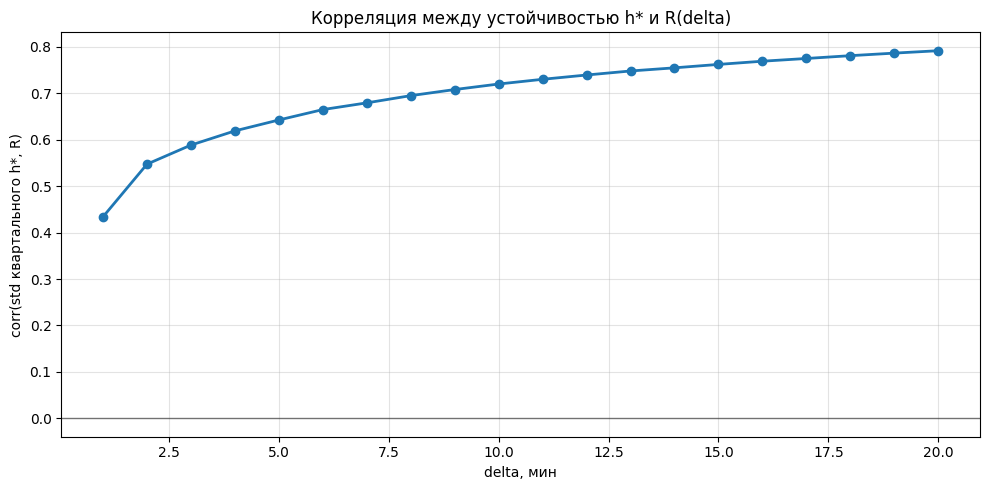

,delta,corr_std_hstar_vs_R
0,1,0.434154
1,2,0.547576
2,3,0.588646
3,4,0.619228
4,5,0.642725
5,6,0.665108
6,7,0.679571
7,8,0.695156
8,9,0.708275
9,10,0.720181


In [56]:
corr_by_delta = (
    retention_R_vs_stability
    .dropna(subset=["std_best_horizon", "R"])
    .groupby("delta")
    .apply(lambda x: x["std_best_horizon"].corr(x["R"]))
    .rename("corr_std_hstar_vs_R")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    corr_by_delta["delta"],
    corr_by_delta["corr_std_hstar_vs_R"],
    marker="o",
    linewidth=2,
)

ax.axhline(0, color="black", linewidth=1, alpha=0.5)

ax.set_title("Корреляция между устойчивостью h* и R(delta)")
ax.set_xlabel("delta, мин")
ax.set_ylabel("corr(std квартального h*, R)")
ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

corr_by_delta

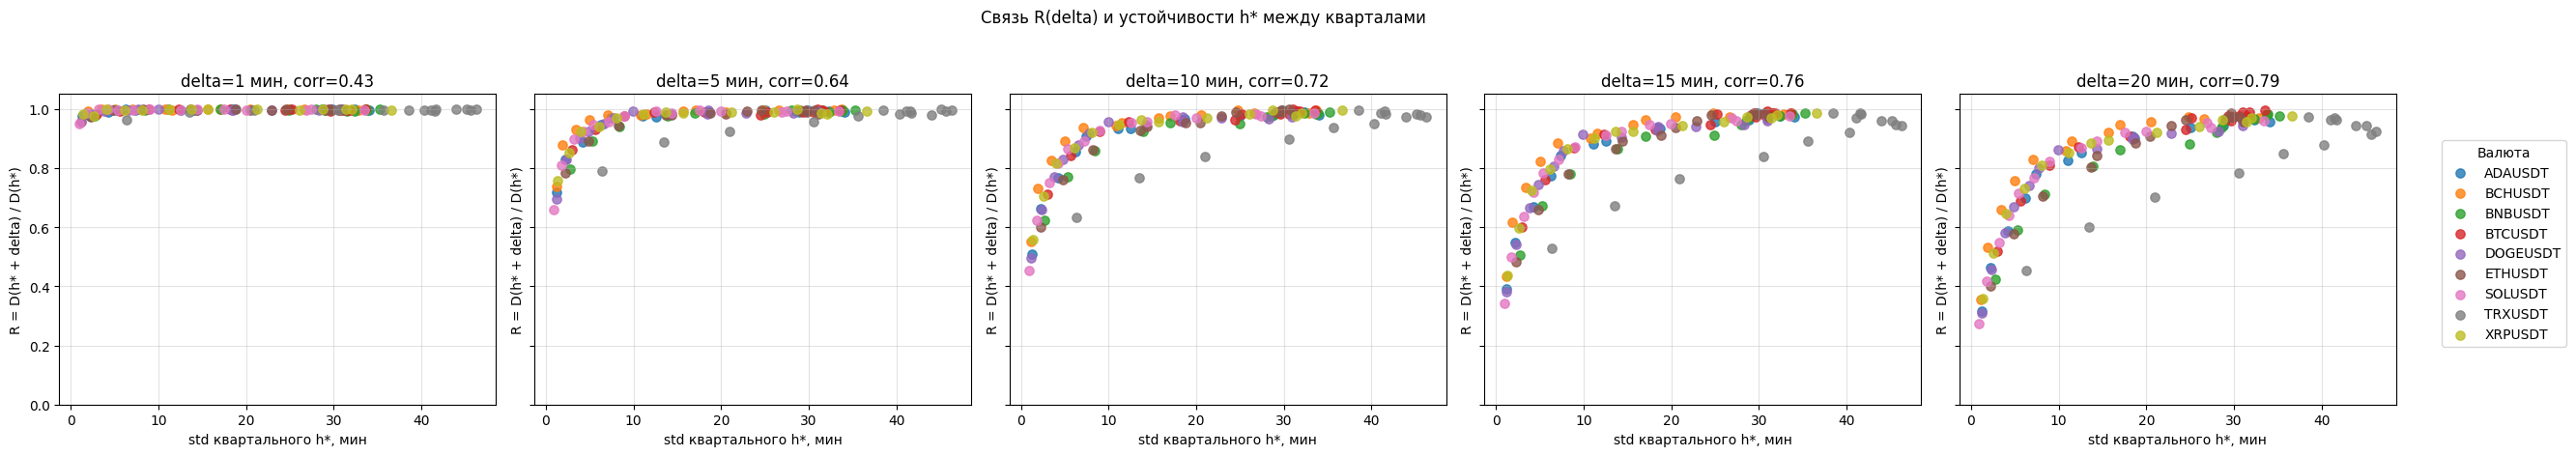

In [57]:
deltas_to_plot = [1, 5, 10, 15, 20]

fig, axes = plt.subplots(
    1,
    len(deltas_to_plot),
    figsize=(5 * len(deltas_to_plot), 4.5),
    sharex=True,
    sharey=True,
)

if len(deltas_to_plot) == 1:
    axes = [axes]

for ax, delta in zip(axes, deltas_to_plot):
    part = retention_R_vs_stability[
        retention_R_vs_stability["delta"] == delta
    ].dropna(subset=["std_best_horizon", "R"])

    for symbol, symbol_part in part.groupby("symbol"):
        ax.scatter(
            symbol_part["std_best_horizon"],
            symbol_part["R"],
            s=45,
            alpha=0.8,
            label=symbol,
        )

    corr = part["std_best_horizon"].corr(part["R"])

    ax.set_title(f"delta={delta} мин, corr={corr:.2f}")
    ax.set_xlabel("std квартального h*, мин")
    ax.set_ylabel("R = D(h* + delta) / D(h*)")
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.35)

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Валюта",
    bbox_to_anchor=(1.01, 0.5),
    loc="center left",
)

fig.suptitle("Связь R(delta) и устойчивости h* между кварталами", y=1.04)
plt.tight_layout()
plt.show()

In [58]:
import numpy as np
import pandas as pd

TARGET_R = 0.9
R_DELTA = 10

nearest_R_09 = (
    retention_R_vs_stability
    .query("delta == @R_DELTA")
    .dropna(subset=["R", "std_best_horizon", "h_star"])
    .assign(
        abs_R_minus_target=lambda x: (x["R"] - TARGET_R).abs()
    )
    .sort_values(["symbol", "abs_R_minus_target", "threshold_pct"])
    .groupby("symbol", as_index=False)
    .head(1)
    .loc[
        :,
        [
            "symbol",
            "threshold_pct",
            "R",
            "abs_R_minus_target",
            "h_star",
            "std_best_horizon",
            "mean_best_horizon",
            "median_best_horizon",
            "min_best_horizon",
            "max_best_horizon",
            "quarters",
        ],
    ]
    .sort_values("symbol")
    .reset_index(drop=True)
)

nearest_R_09

,symbol,threshold_pct,R,abs_R_minus_target,h_star,std_best_horizon,mean_best_horizon,median_best_horizon,min_best_horizon,max_best_horizon,quarters
0,ADAUSDT,0.6,0.906294,0.006294,9,7.382412,13.600000,13.0,4.0,38.0,25
1,BCHUSDT,0.5,0.892184,0.007816,8,4.992327,11.440000,12.0,3.0,23.0,25
2,BNBUSDT,0.5,0.925077,0.025077,9,13.919411,19.000000,16.0,4.0,63.0,25
3,BTCUSDT,0.4,0.924673,0.024673,10,8.942036,16.280000,14.0,3.0,42.0,25
4,DOGEUSDT,0.7,0.917241,0.017241,8,7.709908,14.521739,16.0,2.0,31.0,23
5,ETHUSDT,0.5,0.926497,0.026497,9,13.636715,16.280000,14.0,4.0,73.0,25
6,SOLUSDT,0.7,0.892349,0.007651,11,7.172356,14.521739,13.0,4.0,28.0,23
7,TRXUSDT,0.5,0.897810,0.002190,7,30.540520,35.160000,19.0,4.0,103.0,25
8,XRPUSDT,0.6,0.919568,0.019568,8,8.103497,16.000000,16.0,3.0,29.0,25


In [59]:
nearest_R_09_display = nearest_R_09.copy()

nearest_R_09_display["threshold_pct"] = nearest_R_09_display["threshold_pct"].map(lambda x: f"{x:.1f}%")
nearest_R_09_display["R"] = nearest_R_09_display["R"].round(4)
nearest_R_09_display["abs_R_minus_target"] = nearest_R_09_display["abs_R_minus_target"].round(4)
nearest_R_09_display["h_star"] = nearest_R_09_display["h_star"].astype(int)
nearest_R_09_display["std_best_horizon"] = nearest_R_09_display["std_best_horizon"].round(4)
nearest_R_09_display["mean_best_horizon"] = nearest_R_09_display["mean_best_horizon"].round(4)
nearest_R_09_display["median_best_horizon"] = nearest_R_09_display["median_best_horizon"].round(4)

nearest_R_09_display

,symbol,threshold_pct,R,abs_R_minus_target,h_star,std_best_horizon,mean_best_horizon,median_best_horizon,min_best_horizon,max_best_horizon,quarters
0,ADAUSDT,0.6%,0.9063,0.0063,9,7.3824,13.6000,13.0,4.0,38.0,25
1,BCHUSDT,0.5%,0.8922,0.0078,8,4.9923,11.4400,12.0,3.0,23.0,25
2,BNBUSDT,0.5%,0.9251,0.0251,9,13.9194,19.0000,16.0,4.0,63.0,25
3,BTCUSDT,0.4%,0.9247,0.0247,10,8.9420,16.2800,14.0,3.0,42.0,25
4,DOGEUSDT,0.7%,0.9172,0.0172,8,7.7099,14.5217,16.0,2.0,31.0,23
5,ETHUSDT,0.5%,0.9265,0.0265,9,13.6367,16.2800,14.0,4.0,73.0,25
6,SOLUSDT,0.7%,0.8923,0.0077,11,7.1724,14.5217,13.0,4.0,28.0,23
7,TRXUSDT,0.5%,0.8978,0.0022,7,30.5405,35.1600,19.0,4.0,103.0,25
8,XRPUSDT,0.6%,0.9196,0.0196,8,8.1035,16.0000,16.0,3.0,29.0,25


In [60]:
import numpy as np
import pandas as pd

TARGET_R = 0.9
R_DELTA = 10

nearest_R_le_09 = (
    retention_R_vs_stability
    .query("delta == @R_DELTA")
    .dropna(subset=["R", "std_best_horizon", "h_star"])
    .query("R <= @TARGET_R")
    .sort_values(["symbol", "threshold_pct"], ascending=[True, False])
    .groupby("symbol", as_index=False)
    .head(1)
    .loc[
        :,
        [
            "symbol",
            "threshold_pct",
            "R",
            "h_star",
            "std_best_horizon",
            "mean_best_horizon",
            "median_best_horizon",
            "min_best_horizon",
            "max_best_horizon",
            "quarters",
        ],
    ]
    .sort_values("symbol")
    .reset_index(drop=True)
)

nearest_R_le_09

,symbol,threshold_pct,R,h_star,std_best_horizon,mean_best_horizon,median_best_horizon,min_best_horizon,max_best_horizon,quarters
0,ADAUSDT,0.5,0.854428,7,6.231640,10.800000,11.0,3.0,32.0,25
1,BCHUSDT,0.5,0.892184,8,4.992327,11.440000,12.0,3.0,23.0,25
2,BNBUSDT,0.4,0.857071,7,8.421797,13.480000,12.0,3.0,38.0,25
3,BTCUSDT,0.3,0.841883,7,5.637080,10.120000,9.0,2.0,25.0,25
4,DOGEUSDT,0.6,0.878786,7,6.586608,11.739130,12.0,2.0,31.0,23
5,ETHUSDT,0.4,0.860261,7,8.224557,11.680000,10.0,3.0,43.0,25
6,SOLUSDT,0.7,0.892349,11,7.172356,14.521739,13.0,4.0,28.0,23
7,TRXUSDT,0.5,0.897810,7,30.540520,35.160000,19.0,4.0,103.0,25
8,XRPUSDT,0.5,0.866553,7,6.094260,12.160000,12.0,2.0,24.0,25


In [63]:
plateau_95_full = (
    summary_full
    .assign(threshold_pct=lambda x: x["threshold_pct"].round(1))
    .loc[
        :,
        [
            "symbol",
            "threshold_pct",
            "best_horizon",
            "max_density_per_day",
            "plateau_min_h",
            "plateau_max_h",
            "plateau_width",
        ],
    ]
    .sort_values(["symbol", "threshold_pct"])
    .reset_index(drop=True)
)

plateau_95_full

,symbol,threshold_pct,best_horizon,max_density_per_day,plateau_min_h,plateau_max_h,plateau_width
0,ADAUSDT,0.2,2.0,186.068023,2.0,3.0,2.0
1,ADAUSDT,0.3,4.0,103.808219,3.0,5.0,3.0
2,ADAUSDT,0.4,6.0,66.594939,4.0,8.0,5.0
3,ADAUSDT,0.5,7.0,46.676924,5.0,11.0,7.0
4,ADAUSDT,0.6,9.0,34.296766,6.0,15.0,10.0
...,...,...,...,...,...,...,...
121,XRPUSDT,1.1,19.0,9.860837,11.0,34.0,24.0
122,XRPUSDT,1.2,18.0,8.431644,12.0,43.0,32.0
123,XRPUSDT,1.3,27.0,7.318854,13.0,52.0,40.0
124,XRPUSDT,1.4,28.0,6.425476,15.0,57.0,43.0


In [64]:
TARGET_R = 0.9
R_DELTA = 10

selected_thresholds_R_le_09 = (
    retention_R_vs_stability
    .query("delta == @R_DELTA")
    .dropna(subset=["R"])
    .query("R <= @TARGET_R")
    .sort_values(["symbol", "threshold_pct"], ascending=[True, False])
    .groupby("symbol", as_index=False)
    .head(1)
    [["symbol", "threshold_pct", "R", "h_star", "std_best_horizon"]]
)

plateau_95_for_selected_R = selected_thresholds_R_le_09.merge(
    plateau_95_full,
    on=["symbol", "threshold_pct"],
    how="left",
)

plateau_95_for_selected_R

,symbol,threshold_pct,R,h_star,std_best_horizon,best_horizon,max_density_per_day,plateau_min_h,plateau_max_h,plateau_width
0,ADAUSDT,0.5,0.854428,7,6.231640,7.0,46.676924,5.0,11.0,7.0
1,BCHUSDT,0.5,0.892184,8,4.992327,8.0,37.406035,6.0,13.0,8.0
2,BNBUSDT,0.4,0.857071,7,8.421797,7.0,40.022239,5.0,11.0,7.0
3,BTCUSDT,0.3,0.841883,7,5.637080,7.0,43.208123,5.0,10.0,6.0
4,DOGEUSDT,0.6,0.878786,7,6.586608,7.0,35.786562,4.0,11.0,8.0
5,ETHUSDT,0.4,0.860261,7,8.224557,7.0,42.969558,5.0,11.0,7.0
6,SOLUSDT,0.7,0.892349,11,7.172356,11.0,33.027917,6.0,16.0,11.0
7,TRXUSDT,0.5,0.897810,7,30.540520,7.0,23.569395,5.0,12.0,8.0
8,XRPUSDT,0.5,0.866553,7,6.094260,7.0,38.183011,4.0,11.0,8.0


In [65]:
plateau_95_quarterly = (
    summary_quarterly
    .assign(threshold_pct=lambda x: x["threshold_pct"].round(1))
    .loc[
        :,
        [
            "period_label",
            "period_start",
            "period_end",
            "symbol",
            "threshold_pct",
            "best_horizon",
            "max_density_per_day",
            "plateau_min_h",
            "plateau_max_h",
            "plateau_width",
        ],
    ]
    .sort_values(["symbol", "threshold_pct", "period_start"])
    .reset_index(drop=True)
)

plateau_95_quarterly

,period_label,period_start,period_end,symbol,threshold_pct,best_horizon,max_density_per_day,plateau_min_h,plateau_max_h,plateau_width
0,2020-02-01..2020-03-31,2020-02-01 00:02:00+00:00,2020-03-31 23:59:00+00:00,ADAUSDT,0.2,2.0,251.388303,2.0,2.0,1.0
1,2020-04-01..2020-06-30,2020-04-01 00:00:00+00:00,2020-06-30 23:59:00+00:00,ADAUSDT,0.2,3.0,168.098912,2.0,4.0,3.0
2,2020-07-01..2020-09-30,2020-07-01 00:01:00+00:00,2020-09-30 23:59:00+00:00,ADAUSDT,0.2,2.0,216.171357,2.0,3.0,2.0
3,2020-10-01..2020-12-31,2020-10-01 00:00:00+00:00,2020-12-31 23:59:00+00:00,ADAUSDT,0.2,2.0,219.836779,2.0,2.0,1.0
4,2021-01-01..2021-03-31,2021-01-01 00:00:00+00:00,2021-03-31 23:59:00+00:00,ADAUSDT,0.2,1.0,436.703266,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...
3145,2025-01-01..2025-03-31,2025-01-01 00:00:00+00:00,2025-03-31 23:59:00+00:00,XRPUSDT,1.5,39.0,8.169125,24.0,52.0,29.0
3146,2025-04-01..2025-06-30,2025-04-01 00:00:00+00:00,2025-06-30 23:59:00+00:00,XRPUSDT,1.5,110.0,3.849385,63.0,120.0,58.0
3147,2025-07-01..2025-09-30,2025-07-01 00:00:00+00:00,2025-09-30 23:59:00+00:00,XRPUSDT,1.5,114.0,3.611804,77.0,120.0,44.0
3148,2025-10-01..2025-12-31,2025-10-01 00:00:00+00:00,2025-12-31 23:59:00+00:00,XRPUSDT,1.5,77.0,4.111085,67.0,120.0,54.0


In [ ]:
plateau_95_quarterly_summary = (
    plateau_95_quarterly
    .groupby(["symbol", "threshold_pct"])
    .agg(
        quarters=("period_label", "nunique"),
        mean_best_horizon=("best_horizon", "mean"),
        std_best_horizon=("best_horizon", "std"),
        median_best_horizon=("best_horizon", "median"),
        mean_plateau_min_h=("plateau_min_h", "mean"),
        mean_plateau_max_h=("plateau_max_h", "mean"),
        mean_plateau_width=("plateau_width", "mean"),
        median_plateau_width=("plateau_width", "median"),
        min_plateau_min_h=("plateau_min_h", "min"),
        max_plateau_max_h=("plateau_max_h", "max"),
        std_plateau_width=("plateau_width", "std"),
    )
    .reset_index()
)

plateau_95_quarterly_summary[]

,symbol,threshold_pct,quarters,mean_best_horizon,std_best_horizon,median_best_horizon,mean_plateau_min_h,mean_plateau_max_h,mean_plateau_width,median_plateau_width,min_plateau_min_h,max_plateau_max_h,std_plateau_width
0,ADAUSDT,0.2,25,2.88,1.235584,3.0,2.36,3.72,2.36,2.0,1.0,9.0,1.113553
1,ADAUSDT,0.3,25,5.00,2.217356,5.0,3.60,6.84,4.24,4.0,2.0,17.0,2.046949
2,ADAUSDT,0.4,25,7.68,4.230051,7.0,5.28,11.08,6.80,6.0,2.0,29.0,3.354102
3,ADAUSDT,0.5,25,10.80,6.231640,11.0,7.48,15.12,8.64,9.0,2.0,43.0,4.395831
4,ADAUSDT,0.6,25,13.60,7.382412,13.0,9.92,20.68,11.76,11.0,3.0,58.0,6.186545
...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,XRPUSDT,1.1,25,43.48,26.046625,42.0,29.36,65.76,37.40,37.0,4.0,120.0,20.322401
122,XRPUSDT,1.2,25,52.00,28.687977,53.0,33.04,74.28,42.24,41.0,4.0,120.0,20.035968
123,XRPUSDT,1.3,25,58.72,31.389382,57.0,37.84,81.96,45.12,46.0,4.0,120.0,20.614154
124,XRPUSDT,1.4,25,62.64,32.034981,62.0,43.36,87.44,45.08,48.0,5.0,120.0,18.245821


In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def compute_quarterly_hstar_plateau_coverage(
    summary_full: pd.DataFrame,
    summary_quarterly: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    full_plateau = (
        summary_full
        .assign(threshold_pct=lambda x: x["threshold_pct"].round(1))
        .loc[
            :,
            [
                "symbol",
                "threshold_pct",
                "best_horizon",
                "max_density_per_day",
                "plateau_min_h",
                "plateau_max_h",
                "plateau_width",
            ],
        ]
        .rename(
            columns={
                "best_horizon": "full_best_horizon",
                "max_density_per_day": "full_max_density_per_day",
                "plateau_min_h": "full_plateau_min_h",
                "plateau_max_h": "full_plateau_max_h",
                "plateau_width": "full_plateau_width",
            }
        )
    )

    quarterly_hstar = (
        summary_quarterly
        .assign(threshold_pct=lambda x: x["threshold_pct"].round(1))
        .loc[
            :,
            [
                "period_label",
                "period_start",
                "period_end",
                "symbol",
                "threshold_pct",
                "best_horizon",
                "max_density_per_day",
            ],
        ]
        .rename(
            columns={
                "best_horizon": "quarter_best_horizon",
                "max_density_per_day": "quarter_max_density_per_day",
            }
        )
    )

    coverage_detail = quarterly_hstar.merge(
        full_plateau,
        on=["symbol", "threshold_pct"],
        how="inner",
    )

    coverage_detail["quarter_hstar_in_full_plateau"] = coverage_detail[
        "quarter_best_horizon"
    ].between(
        coverage_detail["full_plateau_min_h"],
        coverage_detail["full_plateau_max_h"],
        inclusive="both",
    )

    coverage_detail["distance_to_full_plateau"] = np.where(
        coverage_detail["quarter_best_horizon"] < coverage_detail["full_plateau_min_h"],
        coverage_detail["full_plateau_min_h"] - coverage_detail["quarter_best_horizon"],
        np.where(
            coverage_detail["quarter_best_horizon"] > coverage_detail["full_plateau_max_h"],
            coverage_detail["quarter_best_horizon"] - coverage_detail["full_plateau_max_h"],
            0,
        ),
    )

    coverage_summary = (
        coverage_detail
        .groupby(["symbol", "threshold_pct"])
        .agg(
            quarters=("period_label", "nunique"),
            quarters_inside_plateau=("quarter_hstar_in_full_plateau", "sum"),
            coverage=("quarter_hstar_in_full_plateau", "mean"),
            full_best_horizon=("full_best_horizon", "first"),
            full_plateau_min_h=("full_plateau_min_h", "first"),
            full_plateau_max_h=("full_plateau_max_h", "first"),
            full_plateau_width=("full_plateau_width", "first"),
            mean_quarter_best_horizon=("quarter_best_horizon", "mean"),
            median_quarter_best_horizon=("quarter_best_horizon", "median"),
            std_quarter_best_horizon=("quarter_best_horizon", "std"),
            mean_distance_to_full_plateau=("distance_to_full_plateau", "mean"),
            max_distance_to_full_plateau=("distance_to_full_plateau", "max"),
        )
        .reset_index()
        .sort_values(["symbol", "threshold_pct"])
    )

    return coverage_detail, coverage_summary


coverage_detail, coverage_summary = compute_quarterly_hstar_plateau_coverage(
    summary_full,
    summary_quarterly,
)

coverage_summary

,symbol,threshold_pct,quarters,quarters_inside_plateau,coverage,full_best_horizon,full_plateau_min_h,full_plateau_max_h,full_plateau_width,mean_quarter_best_horizon,median_quarter_best_horizon,std_quarter_best_horizon,mean_distance_to_full_plateau,max_distance_to_full_plateau
0,ADAUSDT,0.2,25,17,0.68,2.0,2.0,3.0,2.0,2.88,3.0,1.235584,0.44,4.0
1,ADAUSDT,0.3,25,13,0.52,4.0,3.0,5.0,3.0,5.00,5.0,2.217356,0.92,7.0
2,ADAUSDT,0.4,25,14,0.56,6.0,4.0,8.0,5.0,7.68,7.0,4.230051,1.52,14.0
3,ADAUSDT,0.5,25,13,0.52,7.0,5.0,11.0,7.0,10.80,11.0,6.231640,2.16,21.0
4,ADAUSDT,0.6,25,14,0.56,9.0,6.0,15.0,10.0,13.60,13.0,7.382412,2.20,23.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,XRPUSDT,1.1,25,5,0.20,19.0,11.0,34.0,24.0,43.48,42.0,26.046625,15.80,68.0
122,XRPUSDT,1.2,25,6,0.24,18.0,12.0,43.0,32.0,52.00,53.0,28.687977,17.60,61.0
123,XRPUSDT,1.3,25,9,0.36,27.0,13.0,52.0,40.0,58.72,57.0,31.389382,16.60,56.0
124,XRPUSDT,1.4,25,8,0.32,28.0,15.0,57.0,43.0,62.64,62.0,32.034981,16.60,59.0


In [68]:
coverage_for_selected_R = selected_thresholds_R_le_09.merge(
    coverage_summary,
    on=["symbol", "threshold_pct"],
    how="left",
)

coverage_for_selected_R[
    [
        "symbol",
        "threshold_pct",
        "R",
        "h_star",
        "coverage",
        "quarters_inside_plateau",
        "quarters",
        "full_plateau_min_h",
        "full_plateau_max_h",
        "full_plateau_width",
        "mean_distance_to_full_plateau",
        "max_distance_to_full_plateau",
    ]
].sort_values("coverage")

,symbol,threshold_pct,R,h_star,coverage,quarters_inside_plateau,quarters,full_plateau_min_h,full_plateau_max_h,full_plateau_width,mean_distance_to_full_plateau,max_distance_to_full_plateau
7,TRXUSDT,0.5,0.897810,7,0.24,6,25,5.0,12.0,8.0,25.16,91.0
8,XRPUSDT,0.5,0.866553,7,0.28,7,25,4.0,11.0,8.0,3.16,13.0
4,DOGEUSDT,0.6,0.878786,7,0.36,9,25,4.0,11.0,8.0,2.84,20.0
2,BNBUSDT,0.4,0.857071,7,0.36,9,25,5.0,11.0,7.0,4.48,27.0
6,SOLUSDT,0.7,0.892349,11,0.44,11,25,6.0,16.0,11.0,2.28,12.0
0,ADAUSDT,0.5,0.854428,7,0.52,13,25,5.0,11.0,7.0,2.16,21.0
5,ETHUSDT,0.4,0.860261,7,0.56,14,25,5.0,11.0,7.0,3.04,32.0
3,BTCUSDT,0.3,0.841883,7,0.56,14,25,5.0,10.0,6.0,2.36,15.0
1,BCHUSDT,0.5,0.892184,8,0.60,15,25,6.0,13.0,8.0,1.44,10.0


In [78]:
import numpy as np
import pandas as pd


def compute_plateau_from_density(
    density_data: pd.DataFrame,
    plateau_level: float = 0.90,
) -> pd.DataFrame:
    rows = []

    data = density_data.copy()
    data["threshold_pct"] = data["threshold_pct"].round(1)

    for (symbol, threshold_pct), part in data.groupby(["symbol", "threshold_pct"]):
        part = part.dropna(subset=["horizon", "density_per_day"]).sort_values("horizon")

        if part.empty:
            continue

        best_idx = part["density_per_day"].idxmax()
        best = part.loc[best_idx]
        max_density = float(best["density_per_day"])

        plateau = part[part["density_per_day"] >= plateau_level * max_density]

        rows.append(
            {
                "symbol": symbol,
                "threshold_pct": threshold_pct,
                "plateau_level": plateau_level,
                "full_best_horizon": int(best["horizon"]),
                "full_max_density_per_day": max_density,
                "full_plateau_min_h": int(plateau["horizon"].min()),
                "full_plateau_max_h": int(plateau["horizon"].max()),
                "full_plateau_width": int(plateau["horizon"].max() - plateau["horizon"].min() + 1),
            }
        )

    return pd.DataFrame(rows)


def compute_quarterly_hstar_plateau_coverage_from_density(
    density_full: pd.DataFrame,
    summary_quarterly: pd.DataFrame,
    plateau_level: float = 0.90,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    full_plateau = compute_plateau_from_density(
        density_full,
        plateau_level=plateau_level,
    )

    quarterly_hstar = (
        summary_quarterly
        .assign(threshold_pct=lambda x: x["threshold_pct"].round(1))
        .loc[
            :,
            [
                "period_label",
                "period_start",
                "period_end",
                "symbol",
                "threshold_pct",
                "best_horizon",
                "max_density_per_day",
            ],
        ]
        .rename(
            columns={
                "best_horizon": "quarter_best_horizon",
                "max_density_per_day": "quarter_max_density_per_day",
            }
        )
    )

    coverage_detail = quarterly_hstar.merge(
        full_plateau,
        on=["symbol", "threshold_pct"],
        how="inner",
    )

    coverage_detail["quarter_hstar_in_full_plateau"] = coverage_detail[
        "quarter_best_horizon"
    ].between(
        coverage_detail["full_plateau_min_h"],
        coverage_detail["full_plateau_max_h"],
        inclusive="both",
    )

    coverage_detail["distance_to_full_plateau"] = np.where(
        coverage_detail["quarter_best_horizon"] < coverage_detail["full_plateau_min_h"],
        coverage_detail["full_plateau_min_h"] - coverage_detail["quarter_best_horizon"],
        np.where(
            coverage_detail["quarter_best_horizon"] > coverage_detail["full_plateau_max_h"],
            coverage_detail["quarter_best_horizon"] - coverage_detail["full_plateau_max_h"],
            0,
        ),
    )

    coverage_summary = (
        coverage_detail
        .groupby(["symbol", "threshold_pct", "plateau_level"])
        .agg(
            quarters=("period_label", "nunique"),
            quarters_inside_plateau=("quarter_hstar_in_full_plateau", "sum"),
            coverage=("quarter_hstar_in_full_plateau", "mean"),
            full_best_horizon=("full_best_horizon", "first"),
            full_plateau_min_h=("full_plateau_min_h", "first"),
            full_plateau_max_h=("full_plateau_max_h", "first"),
            full_plateau_width=("full_plateau_width", "first"),
            mean_quarter_best_horizon=("quarter_best_horizon", "mean"),
            median_quarter_best_horizon=("quarter_best_horizon", "median"),
            std_quarter_best_horizon=("quarter_best_horizon", "std"),
            mean_distance_to_full_plateau=("distance_to_full_plateau", "mean"),
            max_distance_to_full_plateau=("distance_to_full_plateau", "max"),
        )
        .reset_index()
        .sort_values(["symbol", "threshold_pct"])
    )

    return coverage_detail, coverage_summary


coverage90_detail, coverage90_summary = compute_quarterly_hstar_plateau_coverage_from_density(
    density_full,
    summary_quarterly,
    plateau_level=0.9,
)

coverage90_summary.sort_values("coverage", ascending=False).head(30)

,symbol,threshold_pct,plateau_level,quarters,quarters_inside_plateau,coverage,full_best_horizon,full_plateau_min_h,full_plateau_max_h,full_plateau_width,mean_quarter_best_horizon,median_quarter_best_horizon,std_quarter_best_horizon,mean_distance_to_full_plateau,max_distance_to_full_plateau
1,ADAUSDT,0.3,0.9,25,24,0.96,4,2,7,6,5.00,5.0,2.217356,0.20,5.0
82,ETHUSDT,1.4,0.9,25,24,0.96,58,25,120,96,76.16,84.0,29.733090,0.04,1.0
51,BTCUSDT,1.1,0.9,25,23,0.92,57,23,120,98,77.20,79.0,30.577770,0.64,14.0
55,BTCUSDT,1.5,0.9,25,23,0.92,97,43,120,78,94.36,108.0,29.361085,1.96,33.0
15,BCHUSDT,0.3,0.9,25,23,0.92,4,3,8,6,5.24,6.0,1.899123,0.08,1.0
0,ADAUSDT,0.2,0.9,25,22,0.88,2,2,4,3,2.88,3.0,1.235584,0.20,3.0
41,BNBUSDT,1.5,0.9,25,22,0.88,52,23,120,98,88.52,108.0,33.857692,0.48,9.0
54,BTCUSDT,1.4,0.9,25,22,0.88,87,37,120,84,95.16,106.0,30.972676,1.44,21.0
53,BTCUSDT,1.3,0.9,25,22,0.88,76,32,120,89,90.56,102.0,31.788468,1.20,18.0
52,BTCUSDT,1.2,0.9,25,22,0.88,57,27,120,94,88.48,103.0,33.558556,1.00,19.0


In [79]:
coverage90_for_selected_R = selected_thresholds_R_le_09.merge(
    coverage90_summary,
    on=["symbol", "threshold_pct"],
    how="left",
)

coverage90_for_selected_R[
    [
        "symbol",
        "threshold_pct",
        "R",
        "h_star",
        "coverage",
        "quarters_inside_plateau",
        "quarters",
        "full_plateau_min_h",
        "full_plateau_max_h",
        "full_plateau_width",
        "mean_distance_to_full_plateau",
        "max_distance_to_full_plateau",
    ]
].sort_values("coverage")

,symbol,threshold_pct,R,h_star,coverage,quarters_inside_plateau,quarters,full_plateau_min_h,full_plateau_max_h,full_plateau_width,mean_distance_to_full_plateau,max_distance_to_full_plateau
7,TRXUSDT,0.5,0.897810,7,0.40,10,25,4,16,13,22.56,87.0
4,DOGEUSDT,0.6,0.878786,7,0.56,14,25,3,15,13,1.20,16.0
2,BNBUSDT,0.4,0.857071,7,0.60,15,25,4,14,11,2.96,24.0
8,XRPUSDT,0.5,0.866553,7,0.60,15,25,4,14,11,1.72,10.0
6,SOLUSDT,0.7,0.892349,11,0.68,17,25,5,20,16,1.00,8.0
3,BTCUSDT,0.3,0.841883,7,0.68,17,25,4,13,10,1.36,12.0
5,ETHUSDT,0.4,0.860261,7,0.72,18,25,4,14,11,2.08,29.0
1,BCHUSDT,0.5,0.892184,8,0.80,20,25,5,17,13,0.48,6.0
0,ADAUSDT,0.5,0.854428,7,0.84,21,25,4,14,11,1.16,18.0
